# **Потребление электричества в Португалии**

## **Описание проекта**

Получены данные энергопотребления за несколько лет, на основании которых необходимо построить модель, чтобы предсказать потребление электроэнергии в будущем. Метрика выбирается самостоятельно.

## **Описание данных**

**Диаграммы электрической нагрузки 2011-2014**, источник https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014

### **Основная информация**

Этот набор данных содержит потребление электроэнергии 370 точек/клиентов.

- **Характеристики набора данных**: Временные ряды;
- **Предметная область**: Информатика (Computer Science);
- **Сопутствующие задачи**: Регрессия, Кластеризация;
- **Тип признаков**: Вещественные числа.

**Количество объектов**: 370. **Количество признаков**: 140 256







### **Дополнительная информация**

В наборе данных отсутствуют пропущенные значения.

Значения указаны в кВт за каждые 15 минут. Для перевода в кВт·ч значения необходимо разделить на 4.

Каждый столбец соответствует одному клиенту. Некоторые клиенты были добавлены после 2011 года. В таких случаях потребление считается равным нулю.

Все временные метки приведены по португальскому времени. Однако все дни содержат 96 измерений (24 × 4). Каждый год в день перехода на летнее время (в марте), который длится всего 23 часа, значения с 1:00 до 2:00 равны нулю для всех точек. Каждый год в день перехода на зимнее время (в октябре), который длится 25 часов, значения с 1:00 до 2:00 агрегируют потребление за два часа.

**Пропущенные значения**: Нет

## **Подготовка окружения**

Для будущей работы необходимо подготовить среду. В будущем необходимые библиотеки будут записаны и созхранены в файл requirements.

In [ ]:
# Установка Prophet (если ещё не установлен)
!pip install prophet # для эксперимента

In [ ]:
# основные библиотеки
import pandas as pd          # Библиотека для обработки и анализа табличных данных (DataFrame, Series)
import requests              # Библиотека для выполнения HTTP-запросов (скачивание файлов по URL)
import zipfile               # Модуль для создания, чтения и распаковки ZIP-архивов
import io                    # Модуль для работы с потоками ввода-вывода (например, BytesIO для работы с файлами в памяти)

# замер времени
import time # расчет времени выполнения функций

# математика и статистика
import numpy as np # математические операции и работа с массивами
from scipy.stats import norm # работа со статистикой

# визуализация данных
import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков

# работа с временными рядами
from statsmodels.tsa.seasonal import seasonal_decompose # тренд, сезонность, остатки
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # некоторые графики
from sklearn.model_selection import TimeSeriesSplit # разделение рядов

# модели
import xgboost as xgb # XGBoost
from sklearn.tree import DecisionTreeRegressor # дерево решений
from sklearn.ensemble import RandomForestRegressor # лес случайных деревьев
from prophet import Prophet # сам Prophet

# работа с моделями
from sklearn.model_selection import train_test_split # разбиение на выборки
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # метрики
from sklearn.model_selection import GridSearchCV # перебор гиперпараметров
from prophet.diagnostics import cross_validation, performance_metrics # кросс-валидация и метрики качества для Prophet

In [ ]:
# монтируем гугл диск
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# задаем настройки отображения
from IPython.display import display
# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   # добавила более темный желтый/оранжевый
   NEWYELLOW = '\033[33m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# задаем константы
# для фиксации объектов тренировочной и тестовой выборок, а также в некоторых рандомах
RANDOM_STATE = 42

### **Выводы**

Я загрузила и подключила необходимые для работы библиотеки, настроила отображение.

## **Загрузка данных и первичное ознакомление**

Чтобы не занимать лишнюю память для хранения, буду скачивать файл напрямую из источника и распаковывать архив. Данный архив я изучу лишь кратко, в будущем же я дополнительно обработаю данные, прежде чем изучать их более подробно.

In [ ]:
# 1. Скачиваем и распаковываем архив
url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
print(color.NEWYELLOW + color.BOLD + f"Скачиваю архив..."+ color.END)
response = requests.get(url)

Скачиваю архив...


In [ ]:
# 1.1 Первичное ознакомление (нужно, чтобы подтвердить, что описание верно)
# В будущем эту строку можно пропускать
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('LD2011_2014.txt') as f:
        print(color.NEWYELLOW + color.BOLD + f"Архив распакован. Читаю первые 10 строк для ознакомления..."+ color.END)

        # Читаем ТОЛЬКО ПЕРВЫЕ 10 СТРОК (без загрузки всего файла)
        sample = pd.read_csv(
            f,
            sep=';',
            decimal=',',  # Португальский формат чисел
            nrows=10,     # КЛЮЧЕВОЙ ПАРАМЕТР! Только 10 строк
            parse_dates=[0],  # Первый столбец парсим как дату
            date_parser=lambda x: pd.to_datetime(x, format='%Y-%m-%d %H:%M:%S'),  # ЯВНЫЙ ФОРМАТ! (так дб быстрее, но в будущих версиях может не работать)
            low_memory=False
        )

        print("\n" + "="*80)
        print(color.BLUE + color.BOLD + f"====== ИНФОРМАЦИЯ О ДАННЫХ======"+ color.END)
        print("="*80)

        # 2. Базовая информация
        print(color.BLUE + color.BOLD + f"\n Размер выборки (строки x столбцы): " + color.END + f"{sample.shape}")
        print(color.BLUE + color.BOLD + f"\n Количество клиентов: " + color.END + f"{sample.shape[1] - 1}")  # минус столбец с датой

        # 3. Первые 5 строк (чтобы увидеть структуру)
        print(color.BLUE + color.BOLD + f"\n ПЕРВЫЕ 5 СТРОК:" + color.END)
        print(sample.head())

        # 4. Информация о типах данных
        print(color.BLUE + color.BOLD + f"\n ТИПЫ ДАННЫХ:" + color.END)
        print(sample.dtypes)

        # 5. Транспонируем для наглядности (чтобы клиенты были строками)
        print(color.BLUE + color.BOLD + f"\n ПЕРВЫЕ 5 КЛИЕНТОВ (ТРАНСПОНИРОВАННО):" + color.END)
        sample_t = sample.set_index(sample.columns[0]).T  # Делаем дату индексом и транспонируем
        print(sample_t.head())

        # 6. Статистика по первым клиентам
        print(color.BLUE + color.BOLD + f"\n СТАТИСТИКА РАСПРЕДЕЛЕНИЯ ПОТРЕБЛЕНИЯ СРЕДИ ВСЕХ 370 КЛИЕНТОВ (для каждого из 10 прочитанных моментов времени):" + color.END)
        print(sample_t.describe())

        print("\n" + "="*80)
        print(color.GREEN + color.BOLD + f"V Первичное ознакомление завершено!" + color.END)
        print("="*80)

Архив распакован. Читаю первые 10 строк для ознакомления...

====== ИНФОРМАЦИЯ О ДАННЫХ======

 Размер выборки (строки x столбцы): (10, 371)

 Количество клиентов: 370

 ПЕРВЫЕ 5 СТРОК:
           Unnamed: 0  MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  MT_007  \
0 2011-01-01 00:15:00       0       0       0       0       0       0       0   
1 2011-01-01 00:30:00       0       0       0       0       0       0       0   
2 2011-01-01 00:45:00       0       0       0       0       0       0       0   
3 2011-01-01 01:00:00       0       0       0       0       0       0       0   
4 2011-01-01 01:15:00       0       0       0       0       0       0       0   

   MT_008  MT_009  ...  MT_361  MT_362  MT_363  MT_364  MT_365  MT_366  \
0       0       0  ...       0       0       0       0       0       0   
1       0       0  ...       0       0       0       0       0       0   
2       0       0  ...       0       0       0       0       0       0   
3       0       0  ...       0 

/tmp/ipykernel_6246/1479420058.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  sample = pd.read_csv(


Клиентов действительно 370, и в начало и в конец (с меньшими и наибольшими условными id) попали те самые клиенты, которые пришли позже.

Временные срезы действительно по 15 минут, в рамках которых на первичном обзоре видны относительно близкие значения у соответствующих друг другу статистических показателях.

### **Выводы**

Загрузка исходного архива и первичное ознакомление с ним подтвердило наличие 370 клиентов и временных срезов по 15 минут. Также видно, что клиенты с минимальным и максимальным id присоединились не сразу (позже начала наблюдения).

Ввиду большого веса датасета для более удобной работы с ним могут потребоваться дополнительные преобразования.

## **Преобразования и краткий анализ**

Датасет имеет достаточно большой вес, что может замедляет работу с ним, как можно было понаблюдать ранее. А имеющаяся подробность может не требоваться в рамках поставленной задачи. К тому же необходимо определиться с целевым признаком, который и будет предсказывать будущая модель.

Мощность (то есть возможная нагрузка на сеть) - это то, что должно учитываться еще при проектировании сети. Компанию-поставщика электроэнергии же больше интересует потребление электричества ее клиентами, чтобы вовремя поставлять необходимый запас, но и без излишков (так как хранение лишней энергии также ведет к дополнительным расходам ввиду сложности задачи).

Подобные небольшие срезы (по 15 минут) полезны для полноты информации, но для предсказания удобнее использовать промежутки в час, так как его четверть слишком мала и неудобна для учета и закупок, а сутки же - слишком большая и изменчивая единица, чтобы на нее опираться. К тому же сами единицы потребления также измеряются часами, что служит дополнительным аргументом в пользу выбора именно такого отрезка времени.

Соответственно, наши данные необходимо будет ресемплировать по часу, а затем перевести в соответствующие единицы измерения (из в кВт каждые 15 мин в кВт*ч).

### **Ресемплинг и перевод единиц измерения**

Для удобства работы ресемплирую по часу (тем более, что предсказывают потребление обычно на час-сутки вперед, а не на столь малые интервалы, как четверть часа).

В описание указано про перевод времени, однако с учетом того, что перевод происходит лишь два раза в год давая нам два аномальных часа на этот самый год (один -  нулевым потреблением, другой - с удвоенным), я решила ими пренебречь и не обрабатывать эти аномалии дополнительно ввиду потенциально весьма низкого влияния.

Также сразу переведу данные в нужные единицы измерения и проведу краткий обзор получаемых данных.


In [ ]:
# 1.2 Распаковка с ресемплингом по часу
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('LD2011_2014.txt') as f:
        print(color.NEWYELLOW + color.BOLD + f"Архив распакован. Начинаю загрузку с ресемплингом по часам..." + color.END)

        # 2. Загружаем ВЕСЬ файл (это займет время и память!)
        # Парсим дату, разделитель ; десятичный разделитель ,
        df = pd.read_csv(
            f,
            sep=';',
            decimal=',',
            parse_dates=[0],
            date_parser=lambda x: pd.to_datetime(x, format='%Y-%m-%d %H:%M:%S'), # ЯВНЫЙ ФОРМАТ! (так дб быстрее, но в будущих версиях может не работать)
            low_memory=False
        )

        print(color.GREEN + color.BOLD + f"Загружено {df.shape[0]} строк (15-минутных интервалов)"+ color.END)

        # 3. Делаем столбец с датой индексом
        df.set_index(df.columns[0], inplace=True)
        df.index.name = 'timestamp'

        # 4. ПРОВЕРКА ПРОПУСКОВ (до ресемплинга)
        print("\n" + "="*80)
        print(color.NEWYELLOW + color.BOLD + f"ПРОВЕРКА ПРОПУСКОВ (15-минутные данные)"+ color.END)
        print("="*80)

        # Проверяем пропуски в индексе (датах)
        expected_range = pd.date_range(
            start=df.index.min(),
            end=df.index.max(),
            freq='15T'  # 15 минут
        )

        missing_dates = expected_range.difference(df.index)

        if len(missing_dates) > 0:
            print(color.RED + color.BOLD + f"X Найдено {len(missing_dates)} пропущенных интервалов:"+ color.END)
            print(missing_dates[:10])
        else:
            print(color.GREEN + color.BOLD + f"V Все 15-минутные интервалы присутствуют (пропусков нет)"+ color.END)

        # Проверяем пропуски в значениях (NaN)
        total_nulls = df.isnull().sum().sum()
        if total_nulls > 0:
            print(color.RED + color.BOLD + f"X Найдено {total_nulls} пропущенных значений (NaN)"+ color.END)
        else:
            print(color.GREEN + color.BOLD + f"V Нет пропущенных значений (NaN)"+ color.END)

        print("="*80)

        print(color.NEWYELLOW + color.BOLD + f"Выполняю ресемплинг по часам..."+ color.END)

        # 5. Ресемплинг по часам (суммируем 4 интервала по 15 минут)
        # Получаем сумму мощностей за час (в кВт)
        df_hourly_sum = df.resample('h').sum()

        # 6. ПЕРЕВОДИМ В кВт·ч (ЭНЕРГИЯ)
        # 15 минут = 1/4 часа → энергия за час = (P1+P2+P3+P4) / 4
        df_hourly = df_hourly_sum / 4

        print(color.GREEN + color.BOLD + f"V Ресемплинг завершен! Теперь {df_hourly.shape[0]} строк (часовых интервалов)"+ color.END)
        print(color.GREEN + color.BOLD + f"V Значения переведены из кВт в кВт·ч (энергия за час)"+ color.END)

        # 7. Проверка пропусков ПОСЛЕ ресемплинга
        print("\n" + "="*80)
        print(color.NEWYELLOW + color.BOLD + f"ПРОВЕРКА ПРОПУСКОВ (почасовые данные в кВт·ч)"+ color.END)
        print("="*80)

        expected_range_hourly = pd.date_range(
            start=df_hourly.index.min(),
            end=df_hourly.index.max(),
            freq='h'
        )

        missing_dates_hourly = expected_range_hourly.difference(df_hourly.index)

        if len(missing_dates_hourly) > 0:
            print(color.RED + color.BOLD + f"X Найдено {len(missing_dates_hourly)} пропущенных интервалов:"+ color.END)
            print(missing_dates_hourly[:10])
        else:
            print(color.GREEN + color.BOLD + f"V Все часовые интервалы присутствуют (пропусков нет)"+ color.END)

        # Проверяем NaN после ресемплинга
        total_nulls_hourly = df_hourly.isnull().sum().sum()
        if total_nulls_hourly > 0:
            print(color.RED + color.BOLD + f"X Найдено {total_nulls_hourly} пропущенных значений (NaN)"+ color.END)
        else:
            print(color.GREEN + color.BOLD + f"V Нет пропущенных значений (NaN)"+ color.END)

        print("="*80)

        # ПРИМЕЧАНИЕ ОБ АНОМАЛИЯХ ВРЕМЕНИ
        # В датасете есть 2 дня в году с переходом на летнее/зимнее время (март/октябрь)
        # Это создаёт аномальные часы (23 или 25 часов в сутках)
        # За 5 лет таких часов всего ~10, поэтому их влиянием можно пренебречь
        # Ресемплинг корректно обработает эти случаи (суммирует то, что есть)

        # 8. Показываем результат
        print("\n" + "="*80)
        print(color.BLUE + color.BOLD + f"РЕЗУЛЬТАТ ПОСЛЕ РЕСЕМПЛИНГА"+ color.END)
        print("="*80)
        print(f" - Размер: {df_hourly.shape[0]} строк × {df_hourly.shape[1]} столбцов")
        print(f"- Единицы измерения: кВт·ч (киловатт-часы) - энергия за час")
        print(f"! Примечание: аномальные часы перехода на летнее/зимнее время (≈10 часов за 5 лет) обработаны стандартным ресемплингом, их влиянием пренебрегаем")
        print(color.BLUE + color.BOLD + f"\n Первые 5 строк (первые 5 часов):" + color.END)
        display(df_hourly.head())
        print(color.BLUE + color.BOLD + f"\n Последние 5 строк (последние 5 часов):" + color.END)
        display(df_hourly.tail())
        print(color.BLUE + color.BOLD + f"\n Статистика по клиенту MT_001 (почасовые данные в кВт·ч):" + color.END)
        display(df_hourly['MT_001'].describe())
        print(color.BLUE + color.BOLD + f"\n Статистика по клиенту MT_370 (почасовые данные в кВт·ч):" + color.END)
        display(df_hourly['MT_370'].describe())

        print("\n" + "="*80)
        print(color.GREEN + color.BOLD + f"V Загрузка с ресемплингом завершена!" + color.END)
        print("="*80)

Архив распакован. Начинаю загрузку с ресемплингом по часам...


/tmp/ipykernel_6246/3589373186.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(


Загружено 140256 строк (15-минутных интервалов)

ПРОВЕРКА ПРОПУСКОВ (15-минутные данные)
V Все 15-минутные интервалы присутствуют (пропусков нет)


/tmp/ipykernel_6246/3589373186.py:29: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  expected_range = pd.date_range(


V Нет пропущенных значений (NaN)
Выполняю ресемплинг по часам...
V Ресемплинг завершен! Теперь 35065 строк (часовых интервалов)
V Значения переведены из кВт в кВт·ч (энергия за час)

ПРОВЕРКА ПРОПУСКОВ (почасовые данные в кВт·ч)
V Все часовые интервалы присутствуют (пропусков нет)
V Нет пропущенных значений (NaN)

РЕЗУЛЬТАТ ПОСЛЕ РЕСЕМПЛИНГА
 - Размер: 35065 строк × 370 столбцов
- Единицы измерения: кВт·ч (киловатт-часы) - энергия за час
! Примечание: аномальные часы перехода на летнее/зимнее время (≈10 часов за 5 лет) обработаны стандартным ресемплингом, их влиянием пренебрегаем

 Первые 5 строк (первые 5 часов):


...


 Статистика по клиенту MT_001 (почасовые данные в кВт·ч):


,MT_001
count,35065.000000
mean,3.970672
std,5.714530
min,0.000000
25%,0.000000
50%,1.903553
75%,3.172589
max,34.581218



 Статистика по клиенту MT_370 (почасовые данные в кВт·ч):


,MT_370
count,35065.000000
mean,8722.106397
std,9176.352193
min,0.000000
25%,0.000000
50%,0.000000
75%,17824.324324
max,28459.459459



V Загрузка с ресемплингом завершена!


Данные успешно ресемлированы. Также видны примеры статистики для первого и последнего клиента. И не смотря на то, что они оба присоединились не сразу, видно, что объемы энергопотребления у них очень сильно разняться. То есть вероятно первый клиент является домохозяйством, а последний - объектом производства.

На всякий случай проверю дубликаты. Хоть это маловероятно, но теоретически возможно.

In [ ]:
print(color.BLUE + color.BOLD + f"Найдено дубликатов: "+ color.END)
print(color.BLUE + color.BOLD + f"- строк: "+ color.END + f"{df_hourly.duplicated().sum()}"+ color.END)
print(color.BLUE + color.BOLD + f"- клиентов: "+ color.END + f"{df_hourly.T.duplicated().sum()}"+ color.END)

Найдено дубликатов: 
- строк: 0
- клиентов: 0


Явных дубликатов не обнаружено.

In [ ]:
df_hourly.info() # краткая информация

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35065 entries, 2011-01-01 00:00:00 to 2015-01-01 00:00:00
Freq: h
Columns: 370 entries, MT_001 to MT_370
dtypes: float64(370)
memory usage: 100.3 MB


Имеющиеся данные охватывают период с 2011-01-01 00:00:00 по 2015-01-01 00:00:00.

Теперь, когда строк стало меньше, работать будет удобнее и нагляднее.

### **Новые признаки**

Для предсказания потребления потенциально не важно потребление каждого клиента, а только их совокупности.

Поэтому можно создать новые признаки, чтобы это учесть: количество клиентов и их суммарное потребление.

Однако, так как можно было наблюдать ранее сильное различие клиентов, признак "количество клиентов" (общее) вряд ли будет вносить существенный вклад в предсказание. Можно было бы провести кластеризацию клиентов, и учитывать количество клиентов каждой группы отдельно, однако для этого требуется дополнительная работа, проведение которой при этом может не повлиять достаточно на качество модели в положительную сторону, чтобы имело смысл ее проводить.

Хотя коллега-DA своим анализом (в рамках своего проекта) подтвердила, что клиенты образуют несколько потребительских групп, я попробую обойтись без кластеризации используя лишь общее количество клиентов (как дополнительный признак, потенциально слабый) и их общее потребление (как сильный и основной).

In [ ]:
# СОЗДАНИЕ ДВУХ ПРИЗНАКОВ
print(color.NEWYELLOW + color.BOLD + f"Создание двух агрегатных признаков" + color.END)

# Создаем датафрейм с двумя признаками
df_two_features = pd.DataFrame(index=df_hourly.index).copy()

# 1. Общее потребление (сумма всех клиентов)
df_two_features['total_consumption'] = df_hourly.sum(axis=1)

# 2. Количество активных клиентов (потребление > 0)
df_two_features['active_clients'] = (df_hourly > 0).sum(axis=1)

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f" ДАТАСЕТ С АГРЕГАТНЫМИ ПРИЗНАКАМИ"+ color.END)
print("="*80)

print(f"- Размер: {df_two_features.shape[0]} строк × {df_two_features.shape[1]} столбцов"+ color.END)
print(f"- Первые 5 строк:"+ color.END)
display(df_two_features.head())

print(color.BLUE + color.BOLD + f"\n Статистика:"+ color.END)
display(df_two_features.describe())

print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"V Создание двух новых признаков завершено!"+ color.END)
print("="*80)

Создание двух агрегатных признаков

 ДАТАСЕТ С АГРЕГАТНЫМИ ПРИЗНАКАМИ
- Размер: 35065 строк × 2 столбцов
- Первые 5 строк:


,total_consumption,active_clients
timestamp,,
2011-01-01 00:00:00,51764.567568,158
2011-01-01 01:00:00,66344.627687,158
2011-01-01 02:00:00,65981.054883,158
2011-01-01 03:00:00,66576.533566,158
2011-01-01 04:00:00,64963.552675,158



 Статистика:


,total_consumption,active_clients
count,35065.000000,35065.000000
mean,195551.365542,295.938143
std,83895.020451,80.789981
min,454.479877,118.000000
25%,131454.146829,315.000000
50%,168249.028704,331.000000
75%,248195.154033,348.000000
max,448148.758471,369.000000



V Создание двух новых признаков завершено!


In [ ]:
#проверка хронологического порядка
#if df_two_features.index.is_monotonic == True: # старый pandas
if df_two_features.index.is_monotonic_increasing == True: # новый
    print(color.GREEN + color.BOLD + f"V Данные расположены в хронологическом порядке" + color.END)
else:
    print(color.RED + color.BOLD + f"X Хронологическом порядок нарушен" + color.END)

V Данные расположены в хронологическом порядке


In [ ]:
df_two_features.info() # краткая информация

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35065 entries, 2011-01-01 00:00:00 to 2015-01-01 00:00:00
Freq: h
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   total_consumption  35065 non-null  float64
 1   active_clients     35065 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 1.8 MB


Период охватывается тот же, пропусков и потери дат не появилось.

Вес же подготовленного для будущей работы датафрейма стал гораздо меньше.


### **Сохранение датасета**

Теперь есть датасет, который станет исходником для будущей работы. Для того, чтобы ускорить работу  при необходимости в будущем (не обрабатывать исходный архив заново), сохраню его.

In [ ]:
# Сохраняем агрегированный датасет в CSV
df_two_features.to_csv('df_two_features.csv')
print(color.GREEN + color.BOLD + "V Датасет сохранён в файл 'df_two_features.csv'" + color.END)

V Датасет сохранён в файл 'df_two_features.csv'


Теперь в будущем можно будет приступать к работе сразу со следующего раздела (предварительно подключив необходимые библиотеки из раздела "Подготовка окружения").

In [ ]:
# Удаляем df_hourly (освобождаем память)
# подразумевается, что все сохранилось успешно (что проверили далее)
# удаляем здесь, а не далее, чтобы запускать потом со следующего раздела
del df_hourly

### **Выводы**

Я загрузила файл, ресемплировав его по часу и преобразовав единицы измерения из кВт в кВт·ч. Дополнительной обработки аномальных часов (получаемых при переводе времени на летнее и зимнее время) я не проводила ввиду потенцильно слабого влияния на точность модели ввиду их малого количества.

Первичное ознакомление с преобразуемыми таким образом данными показало, что:
- строк стало меньше;
- данные охватывают период с 2011-01-01 00:00:00 по 2015-01-01 00:00:00;
- пропуски как в 15-минутных, так и в получившихся часовых интервалах отсутствуют;
- явные дубликаты отсутствуют;
- потенциально клиенты могут делиться на несколько групп с разным потребительским поведением.

На основе данного датасета для будущих анализа и работы с моделью я создала новый датафрейм с агрешированными признаками: количество активных клиентов (потребление больше ноля) и общее потребление всех клиентов. Дополнительная проверка показала, что данные в нем расположены в хронологическом порядке.

Полученный в итоге датасет с агрегированными признаками был отдельно сохранен для удобства будущей работы, а датасет-исходник - удален для очистки памяти.


## **Анализ**

Теперь, когда получен обновленный упрощенный датасет, можно его проанализировать. Анализ я буду проводить именно для потребляемого электричества (так как интересует именно оно, так как является целевым признаком), а не для количества клиентов (которые, из-за разнородности вряд ли будут как-то сильно влиять на результат в рамках решения обойтись без кластеризации).

In [ ]:
# задаем целевой признак
target = 'total_consumption'

### **Загрузка**

In [ ]:
# задаем настройки отображения
# раньше не подключала, так как было очень много столбцов
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format ='{:,.2f}'.format
sns.set_theme(style='whitegrid', palette='pastel')
sns.set_context(
    'notebook',
    rc={
        'font.size':12,
        'axes.titlesize':16,
        'axes.labelsize':12,
        'legend.fontsize':12,
        'figure.figsize':(14, 7)
    }
)

Загружу сохраненный и помещенный на диск файл ранее датасет.

In [ ]:
# загружаем
try:
  df_two_features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Стажировка (Экосистема Альфа)/Временные ряды/Электричество/df_two_features.csv',
                                index_col=0,
                                parse_dates=True).asfreq('h')  # восстанавливает частоту

  print(color.GREEN + color.BOLD + f"Файл успешно загружен"+ color.END)
except:
  print(color.RED + color.BOLD + f"Файл не загружен"+ color.END)

Файл успешно загружен


In [ ]:
df_two_features.head() # первые строки

,total_consumption,active_clients
timestamp,,
2011-01-01 00:00:00,"51,764.57",158
2011-01-01 01:00:00,"66,344.63",158
2011-01-01 02:00:00,"65,981.05",158
2011-01-01 03:00:00,"66,576.53",158
2011-01-01 04:00:00,"64,963.55",158


In [ ]:
df_two_features.info() # краткая информация

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35065 entries, 2011-01-01 00:00:00 to 2015-01-01 00:00:00
Freq: h
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   total_consumption  35065 non-null  float64
 1   active_clients     35065 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 821.8 KB


Благодаря перезагрузке файла pandas оптимизировал данные, и теперь они занимают меньше места, а значит работа с ними будет быстрее.

In [ ]:
# Удаляем df_hourly (освобождаем память)
# если не был удален раннее и вся работа(запуск ноутбука) велась с самого начала,
# то после проверки загруженного результата
# иначе у нас уже нет этого датафрейма
#del df_hourly

### **Анализ временного ряда**

Для начала посмотрю общее поведение ряда. Так как у данных разные масштабы, то на одном графике отобразить наглядно не выйдет.

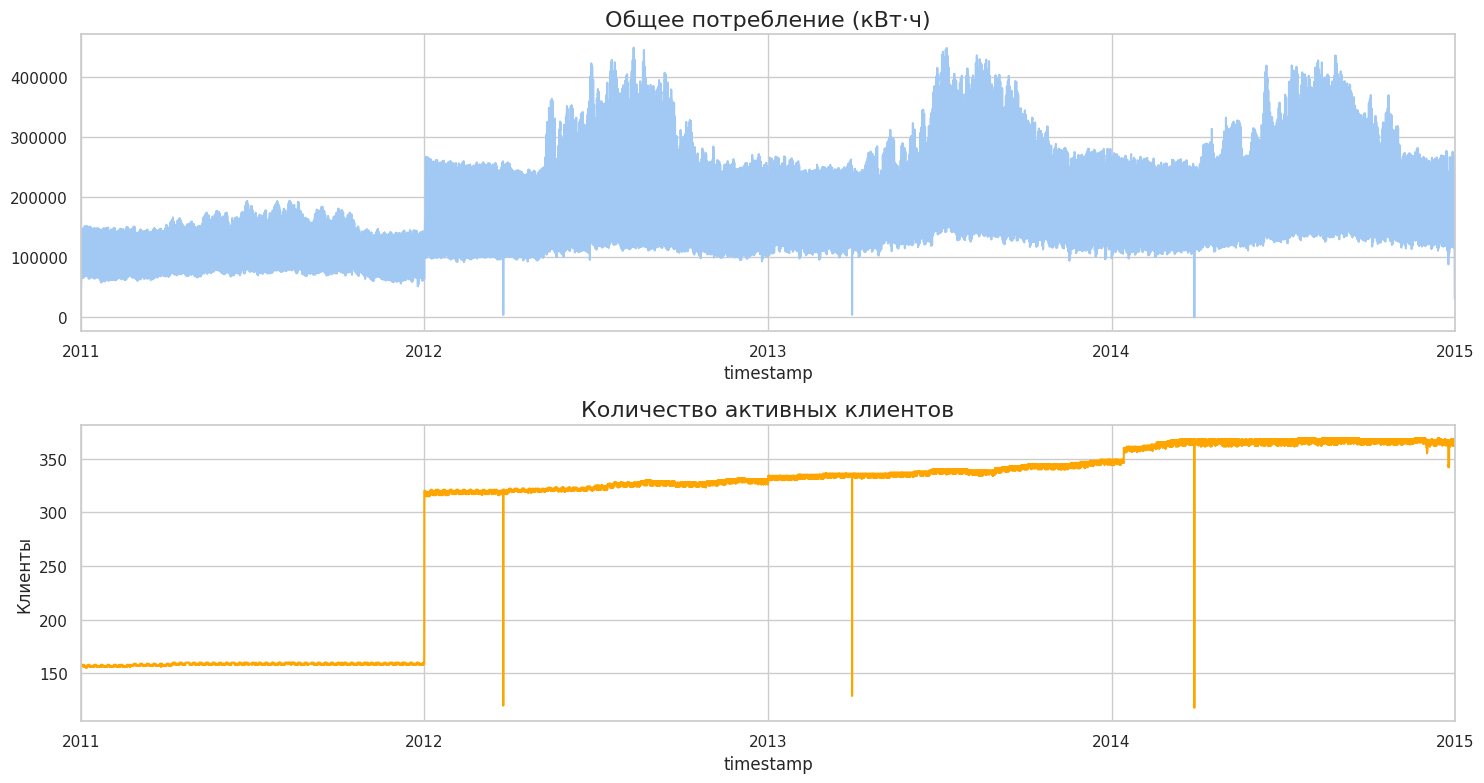

In [ ]:
# строим графики
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

df_two_features['total_consumption'].plot(ax=axes[0])
axes[0].set_title('Общее потребление (кВт·ч)')

df_two_features['active_clients'].plot(ax=axes[1], color='orange')
axes[1].set_title('Количество активных клиентов')
axes[1].set_ylabel('Клиенты')

plt.tight_layout()
plt.show()

Видно, что в начале 2012 года количество клиентов заметно (почти в два раза) увеличилось. Что отразилось резким скачком потребления. Также был небольшой прирост количества клиентов в начале 2014.

Также на обоих графиках видны переводы часов назад (на летнее время в марте), когда количество и клиентов, и потребленного электричества падает до нуля. А вот аналогичного скачка при переводе вперед в октябре на общем графике не наблюдается.

Также видно, что летом тратится гораздо больше электричества (это может быть вполне связано с теплым климатом Португалии). И разница эта сильнее заметна после наплыва клиентов в 2012 году.

In [ ]:
# числовое описание данных (с транспонированием)
df_two_features.describe().T

,count,mean,std,min,25%,50%,75%,max
total_consumption,35065.0,195551.365542,83895.020451,454.479877,131454.146829,168249.028704,248195.154033,448148.758471
active_clients,35065.0,295.938143,80.789981,118.000000,315.000000,331.000000,348.000000,369.000000



ОБЩЕЕ ПОТРЕБЛЕНИЕ
Описательная статистика:
count     35065.000000
mean     195551.365542
std       83895.020451
min         454.479877
25%      131454.146829
50%      168249.028704
75%      248195.154033
max      448148.758471
Name: total_consumption, dtype: float64


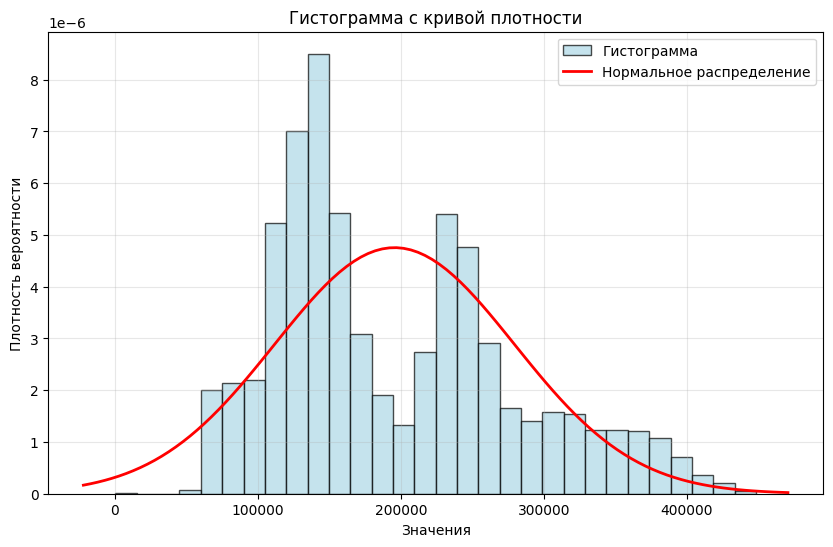

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ОБЩЕЕ ПОТРЕБЛЕНИЕ"+ color.END)
print("="*80)

# выведу гистограмму
print(color.BLUE + color.BOLD + f"Описательная статистика:"+ color.END)
print(df_two_features['total_consumption'].describe())

# Более детальная гистограмма с плотностью
plt.figure(figsize=(10, 6))

# Гистограмма с кривой плотности
plt.hist(df_two_features['total_consumption'], bins=30, density=True, alpha=0.7, color='lightblue',
         edgecolor='black', label='Гистограмма')


# Кривая плотности
mu, std = norm.fit(df_two_features['total_consumption'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label='Нормальное распределение')

plt.xlabel('Значения')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма с кривой плотности')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Два пика еще раз косвенно подтверждает наличие двух групп с разным потребительским поведением. Поэтому, чтобы не возвращаться обратно и не группировать клиентов, потенциально проще может оказаться работать через лаги и скользящие, как я и решила ранее.

Понаблюдаю поведение ряда при декомпозиции.


ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА

 Выполняю аддитивную декомпозицию для total_consumption...


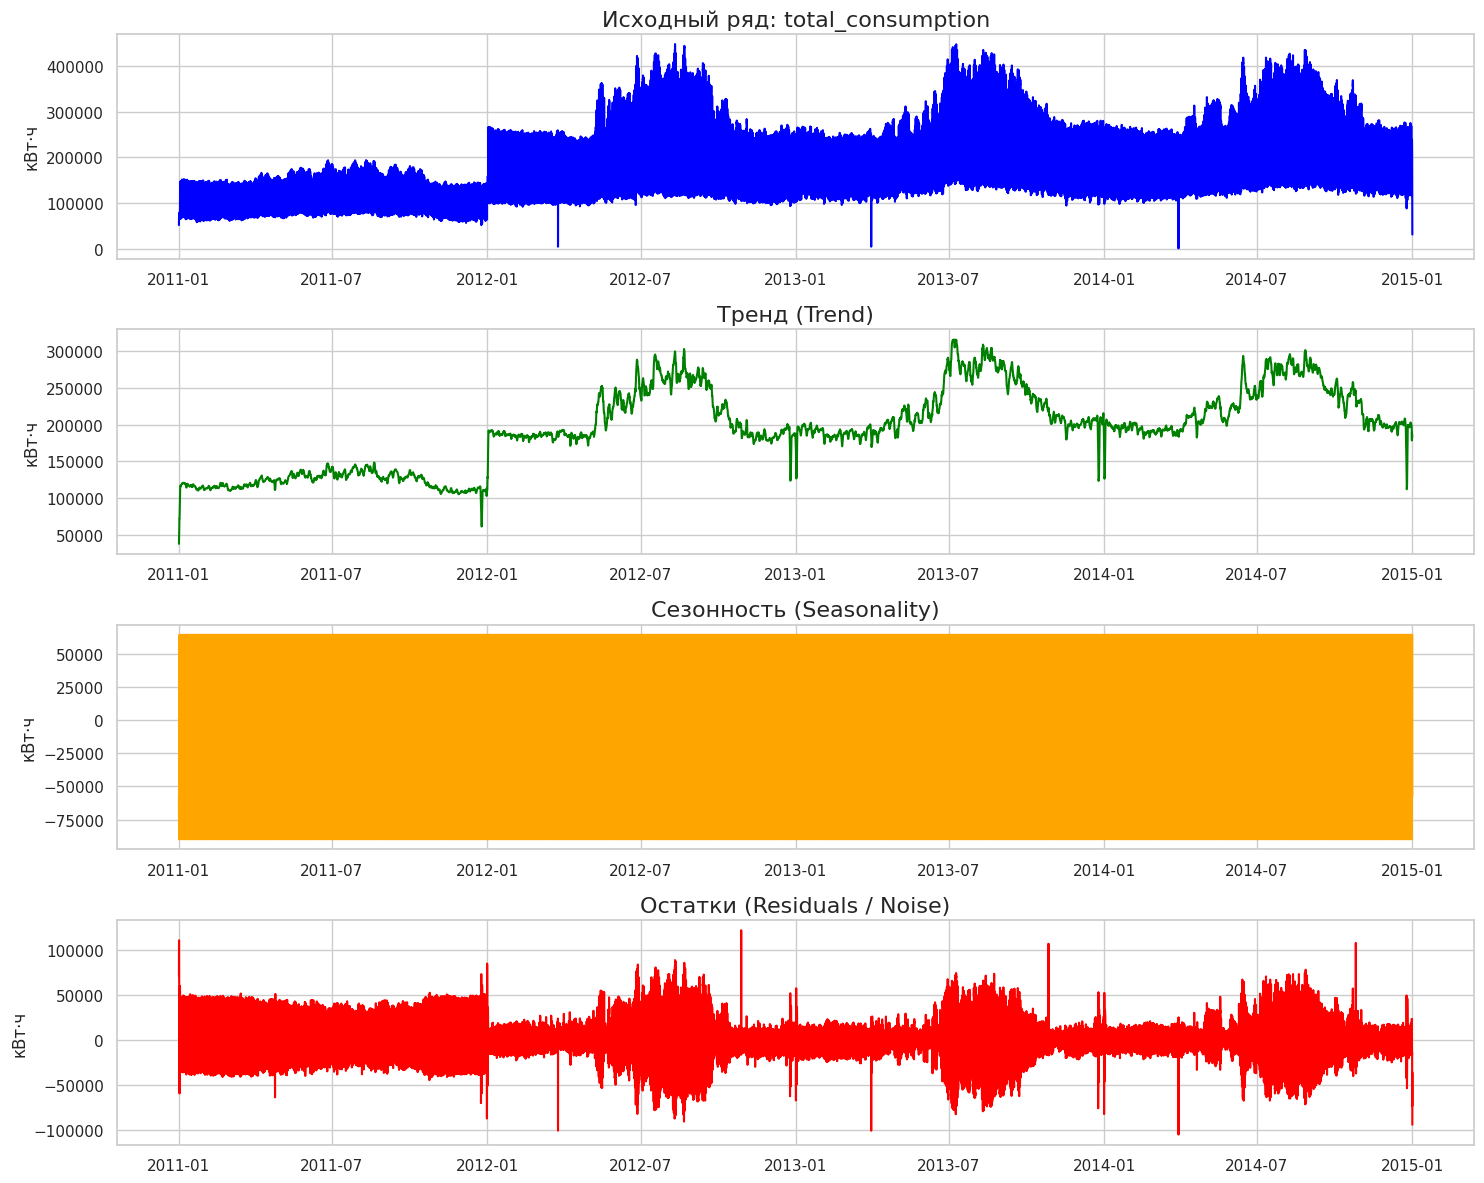


✅ Декомпозиция завершена!


In [ ]:
print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА"+ color.END)
print("="*80)

# Выбираем целевой признак для декомпозиции
# (можно разложить total_consumption или active_clients)
print(color.NEWYELLOW + color.BOLD + f"\n Выполняю аддитивную декомпозицию для {target}..." + color.END)

# Для декомпозиции нужен период (сезонность)
# У нас почасовые данные, поэтому:
# - суточная сезонность = 24 часа
# - недельная сезонность = 24 * 7 = 168 часов
period = 24  # суточная сезонность

# Выполняем декомпозицию (модель = 'additive' или 'multiplicative')
decomposed = seasonal_decompose(
    df_two_features[target],
    # аддитивная модель: y = trend + season + resid
    # В мультипликативной модели y = trend × seasonal × resid:
    model='additive',  # или 'multiplicative'
    period=period,
    extrapolate_trend='freq'  # чтобы избежать NaN на краях
)

# Визуализация
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# 1. Исходный ряд
axes[0].plot(df_two_features.index, df_two_features[target], color='blue')
axes[0].set_title(f'Исходный ряд: {target}')
axes[0].set_ylabel('кВт·ч')
axes[0].grid(True)

# 2. Тренд
axes[1].plot(decomposed.trend.index, decomposed.trend, color='green')
axes[1].set_title('Тренд (Trend)')
axes[1].set_ylabel('кВт·ч')
axes[1].grid(True)

# 3. Сезонность
axes[2].plot(decomposed.seasonal.index, decomposed.seasonal, color='orange')
axes[2].set_title('Сезонность (Seasonality)')
axes[2].set_ylabel('кВт·ч')
axes[2].grid(True)

# 4. Остатки (шум)
axes[3].plot(decomposed.resid.index, decomposed.resid, color='red')
axes[3].set_title('Остатки (Residuals / Noise)')
axes[3].set_ylabel('кВт·ч')
axes[3].grid(True)

plt.tight_layout()
plt.show()

print("\n✅ Декомпозиция завершена!")
print("="*80)

Можно увидеть, что остатки получаются слишком большие, и понаблюдать в них некую сезонность. То есть аддитивная модель потенциально не подойдет.

Также на графике плохо видна сама сезонность. Поэтому изменю масштаб, выведя более мелкие отрезки времени.

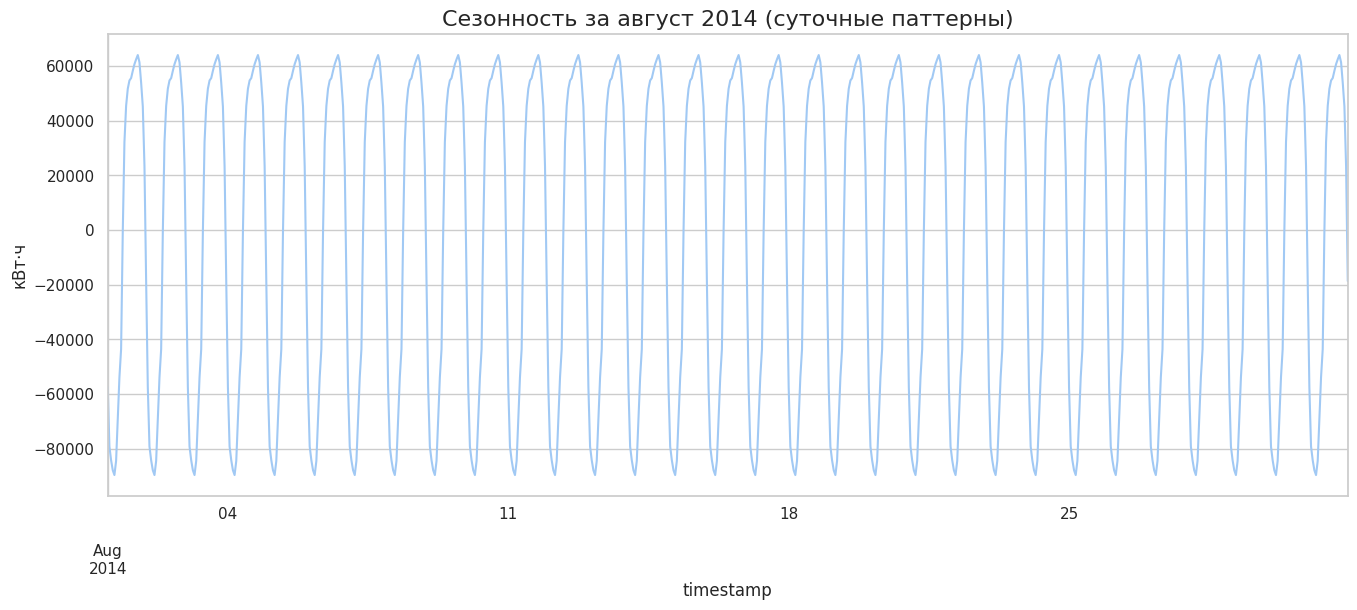

In [ ]:
# Смотрим сезонность за август 2014
plt.figure(figsize=(16, 6))
decomposed.seasonal['2014-08-01':'2014-08-31'].plot()
plt.title('Сезонность за август 2014 (суточные паттерны)')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

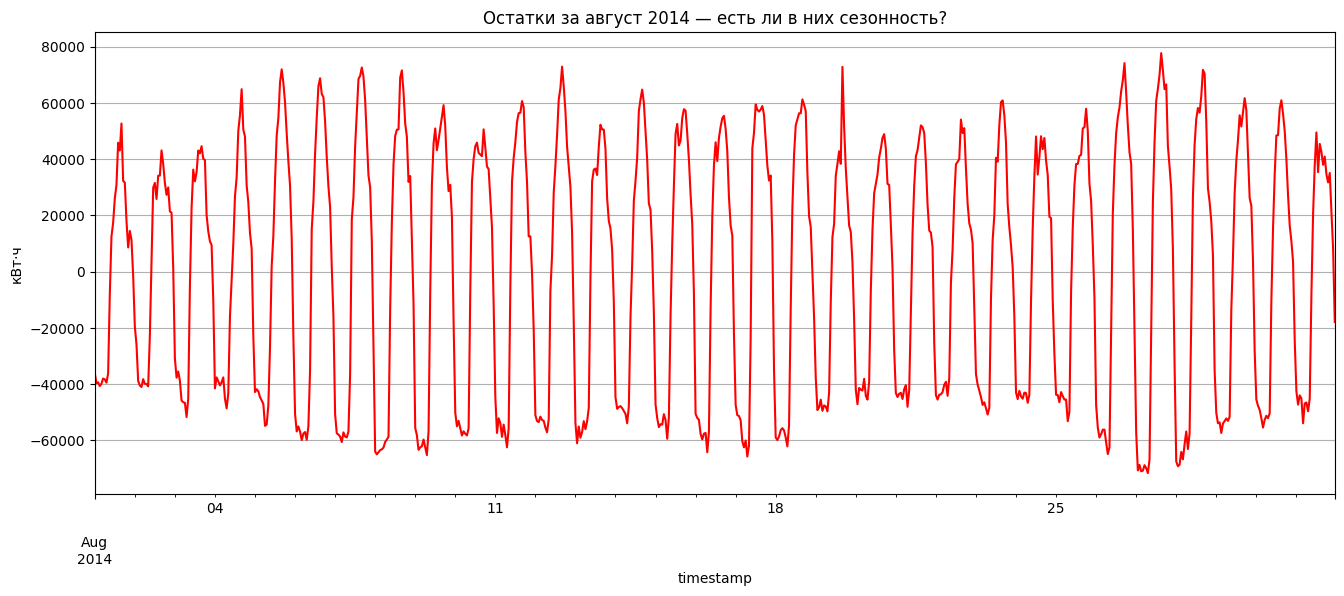

In [ ]:
# Визуализируем остатки за август 2014
plt.figure(figsize=(16, 6))
decomposed.resid['2014-08-01':'2014-08-31'].plot(color='red')
plt.title('Остатки за август 2014 — есть ли в них сезонность?')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

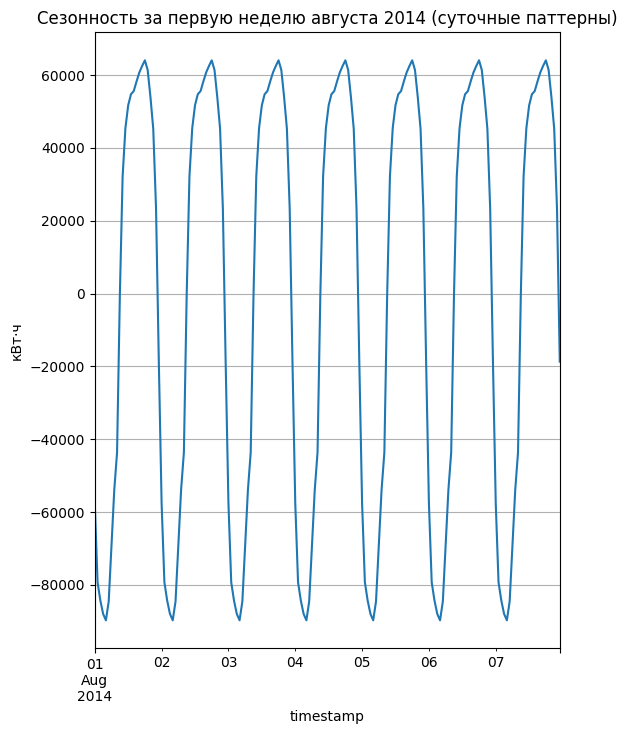

In [ ]:
# Смотрим сезонность для первой недели августа 2014
plt.figure(figsize=(6, 8))
decomposed.seasonal['2014-08-1':'2014-08-07'].plot()
plt.title('Сезонность за первую неделю августа 2014 (суточные паттерны)')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

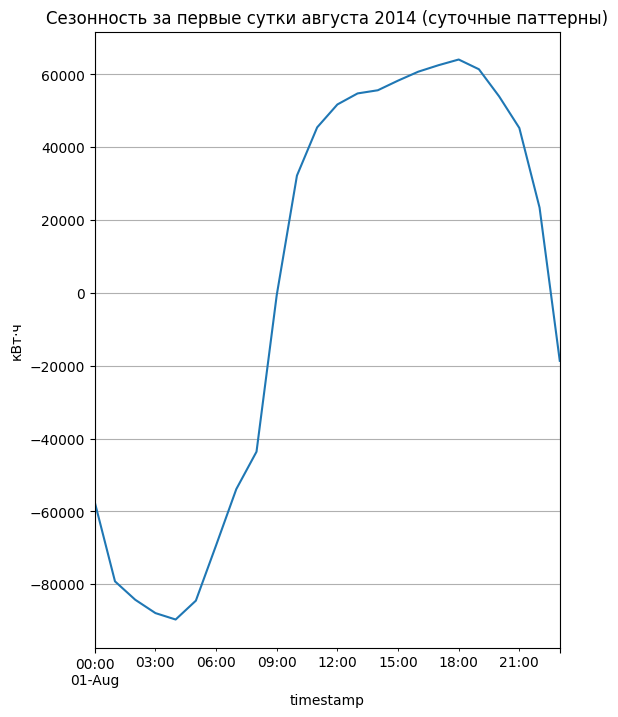

In [ ]:
# Смотрим сезонность для первого дня августа 2014
plt.figure(figsize=(6, 8))
decomposed.seasonal['2014-08-1':'2014-08-01'].plot()
plt.title('Сезонность за первые сутки августа 2014 (суточные паттерны)')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

Здесь сезонность в рамках суток видна хорошо (что можно будет использовать при создании новых признаков).

Также можно понаблюдать большие остатки, также имеющие сезонность.

Разложу данные немного иначе.


ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА

 Выполняю мультипликативную декомпозицию для total_consumption...


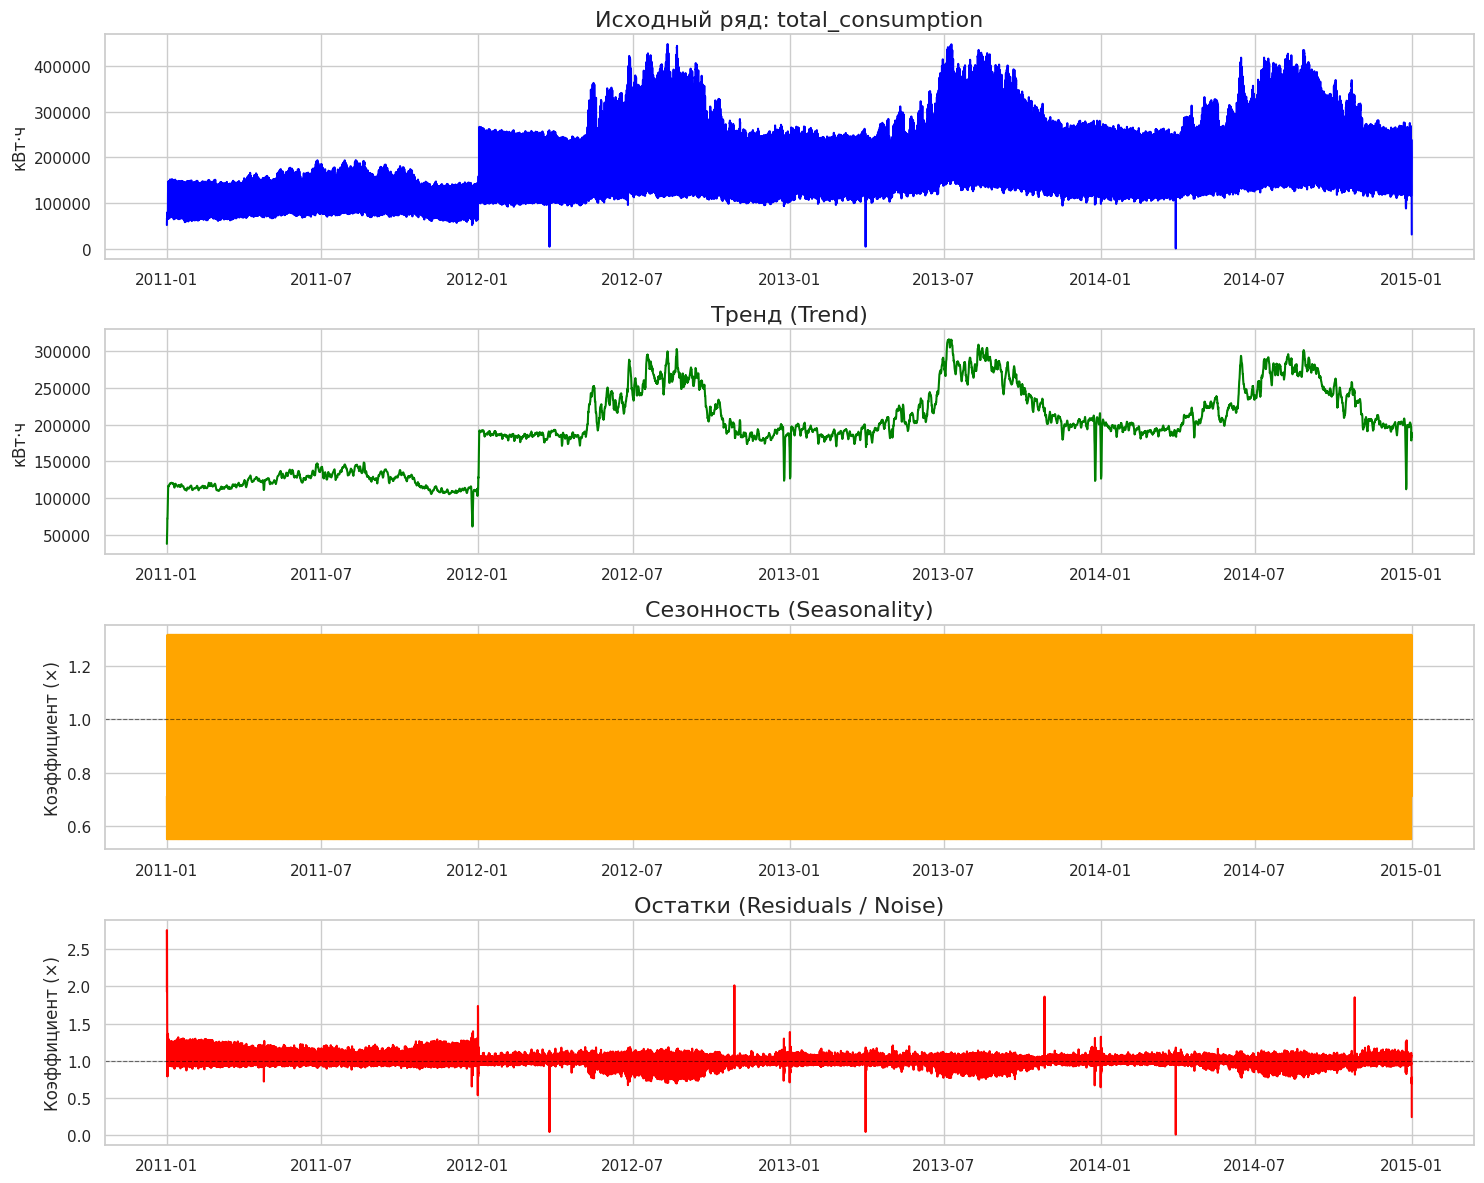


✅ Декомпозиция завершена!


In [ ]:
print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА"+ color.END)
print("="*80)

# Выбираем целевой признак для декомпозиции
# (можно разложить total_consumption или active_clients)
print(color.NEWYELLOW + color.BOLD + f"\n Выполняю мультипликативную декомпозицию для {target}..." + color.END)

# Для декомпозиции нужен период (сезонность)
# У нас почасовые данные, поэтому:
# - суточная сезонность = 24 часа
# - недельная сезонность = 24 * 7 = 168 часов
period = 24  # суточная сезонность

# Выполняем декомпозицию (модель = 'additive' или 'multiplicative')
decomposed_multi = seasonal_decompose(
    df_two_features[target],
    # аддитивная модель: y = trend + season + resid
    # В мультипликативной модели y = trend × seasonal × resid
    model='multiplicative',  # или 'additive'
    period=period,
    extrapolate_trend='freq'  # чтобы избежать NaN на краях
)

# Визуализация
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# 1. Исходный ряд
axes[0].plot(df_two_features.index, df_two_features[target], color='blue')
axes[0].set_title(f'Исходный ряд: {target}')
axes[0].set_ylabel('кВт·ч')
axes[0].grid(True)

# 2. Тренд
axes[1].plot(decomposed_multi.trend.index, decomposed_multi.trend, color='green')
axes[1].set_title('Тренд (Trend)')
axes[1].set_ylabel('кВт·ч')
axes[1].grid(True)


# Добавлен axhline(y=1.0) на графиках сезонности и остатков.
# Для мультипликативной модели:
# - Сезонность должна колебаться вокруг 1.0
# - Остатки должны колебаться вокруг 1.0
# Без этих линий непонятно, где "база" и правильно ли работает модель.
# 3. Сезонность
axes[2].plot(decomposed_multi.seasonal.index, decomposed_multi.seasonal, color='orange')
axes[2].set_title('Сезонность (Seasonality)')
# axes[2].set_ylabel('кВт·ч')
axes[2].set_ylabel('Коэффициент (×)')  # <--- поменяли для мультипликативной модели
axes[2].axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)  # <--- ДОБАВИЛИ!
axes[2].grid(True)

# 4. Остатки (шум)
axes[3].plot(decomposed_multi.resid.index, decomposed_multi.resid, color='red')
axes[3].set_title('Остатки (Residuals / Noise)')
#axes[3].set_ylabel('кВт·ч')
axes[3].set_ylabel('Коэффициент (×)')  # <--- поменяли для мультипликативной модели
axes[3].axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)  # <--- ДОБАВИЛИ!
axes[3].grid(True)

plt.tight_layout()
plt.show()

print("\n✅ Декомпозиция завершена!")
print("="*80)

Остатки выглядят более аккуратно.

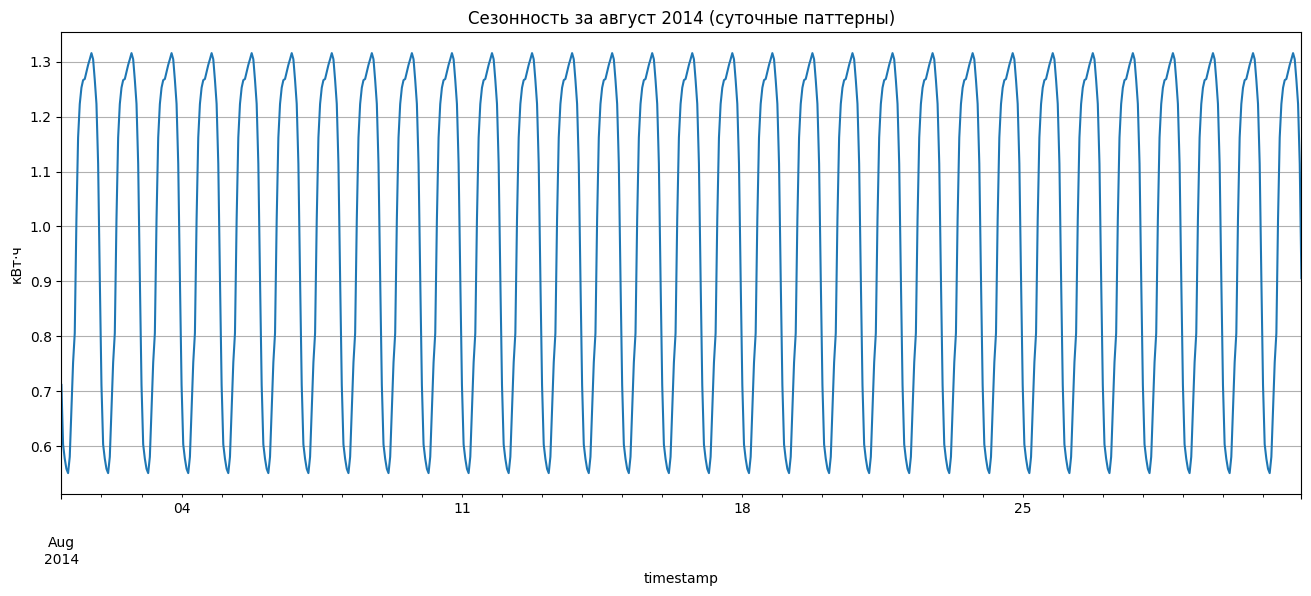

In [ ]:
# Смотрим сезонность за август 2014
plt.figure(figsize=(16, 6))
decomposed_multi.seasonal['2014-08-01':'2014-08-31'].plot()
plt.title('Сезонность за август 2014 (суточные паттерны)')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

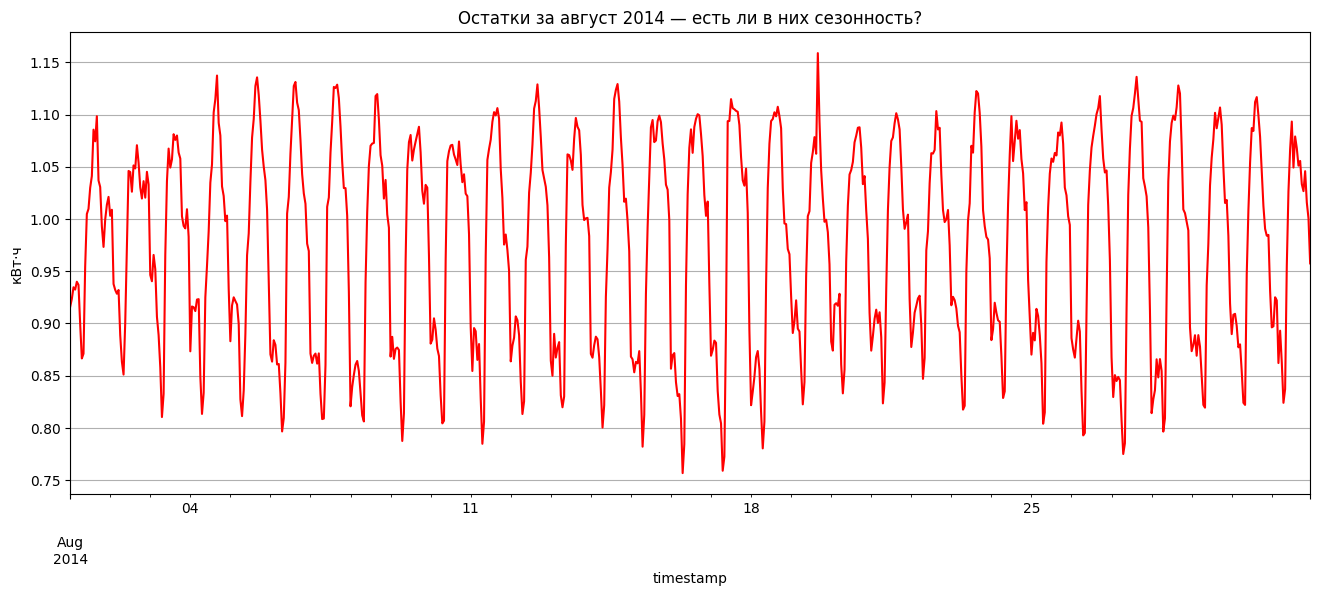

In [ ]:
# Визуализируем остатки за август 2014
plt.figure(figsize=(16, 6))
decomposed_multi.resid['2014-08-01':'2014-08-31'].plot(color='red')
plt.title('Остатки за август 2014 — есть ли в них сезонность?')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

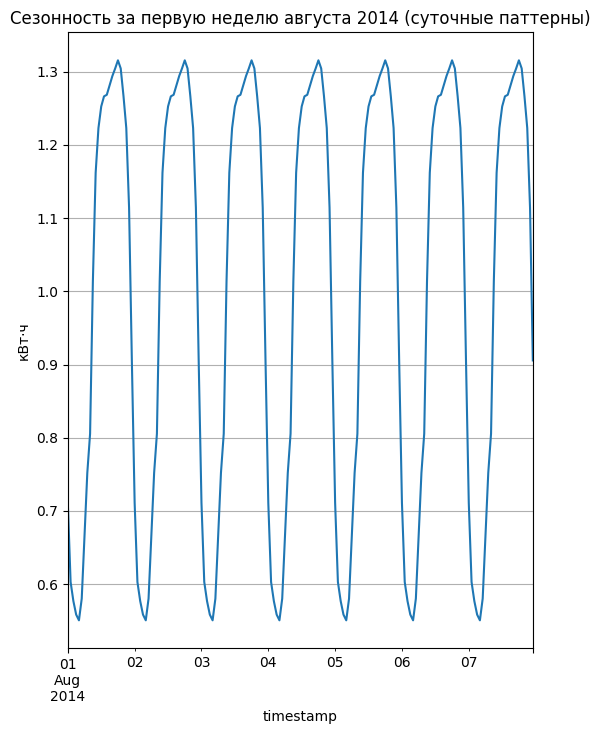

In [ ]:
# Смотрим сезонность для первой недели августа 2014
plt.figure(figsize=(6, 8))
decomposed_multi.seasonal['2014-08-1':'2014-08-07'].plot()
plt.title('Сезонность за первую неделю августа 2014 (суточные паттерны)')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

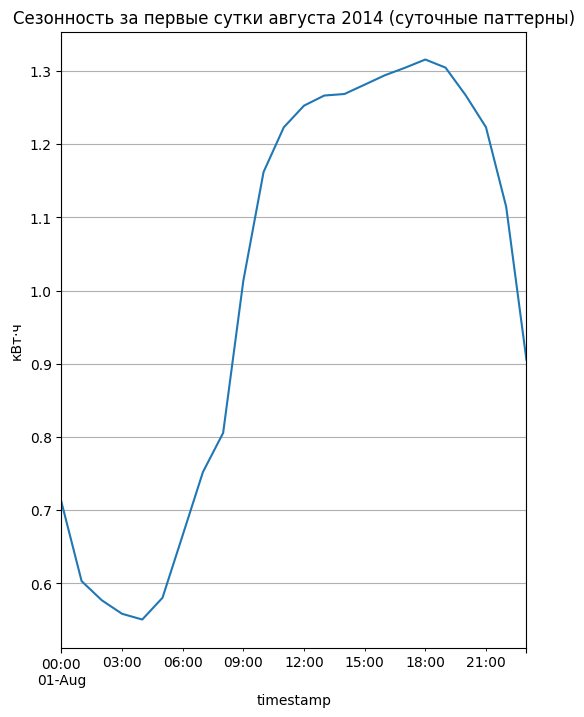

In [ ]:
# Смотрим сезонность для первого дня августа 2014
plt.figure(figsize=(6, 8))
decomposed_multi.seasonal['2014-08-1':'2014-08-01'].plot()
plt.title('Сезонность за первые сутки августа 2014 (суточные паттерны)')
plt.ylabel('кВт·ч')
plt.grid(True)
plt.show()

Графики при обоих вариантах декомпозиции выглядят очень схоже. Проверю разницу математически.

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"СРАВНЕНИЕ СЕЗОННОСТИ (ЧИСЛА)" + color.END)
print("="*80)

# Сравниваем конкретные числа за один и тот же час (например, 1 августа 2014, 20:00)
date_sample = '2014-08-01 20:00:00'

print(color.BLUE + color.BOLD + f"\nЗначения для {date_sample}:" + color.END)
print(f"  Аддитивная сезонность: {decomposed.seasonal.loc[date_sample]:.4f} (кВт·ч)")
print(f"  Мультипликативная сезонность: {decomposed_multi.seasonal.loc[date_sample]:.4f} (коэффициент)")

print(color.BLUE + color.BOLD + f"\nСтатистика за весь период:"+ color.END)
print(f"  Аддитивная: среднее = {decomposed.seasonal.mean():.4f}, std = {decomposed.seasonal.std():.4f}")
print(f"  Мультипликативная: среднее = {decomposed_multi.seasonal.mean():.4f}, std = {decomposed_multi.seasonal.std():.4f}")


СРАВНЕНИЕ СЕЗОННОСТИ (ЧИСЛА)

Значения для 2014-08-01 20:00:00:
  Аддитивная сезонность: 53946.3635 (кВт·ч)
  Мультипликативная сезонность: 1.2667 (коэффициент)

Статистика за весь период:
  Аддитивная: среднее = -1.6398, std = 59799.2187
  Мультипликативная: среднее = 1.0000, std = 0.2945


In [ ]:
resid_add = decomposed.resid.dropna()
resid_mul = decomposed_multi.resid.dropna()

print(color.BLUE + color.BOLD + f"СРАВНЕНИЕ ОСТАТКОВ (ошибок):" + color.END)
print(f"  Аддитивная: std = {resid_add.std():.2f} кВт·ч")
print(f"  Мультипликативная: std = {resid_mul.std():.2f} (коэффициент)")

# Чтобы сравнить в одних единицах, переведем мультипликативные остатки в кВт·ч
trend = decomposed_multi.trend.dropna()
seasonal = decomposed_multi.seasonal.dropna()
resid_mul_abs = trend * seasonal * (resid_mul - 1)  # абсолютная ошибка

print(color.BLUE + color.BOLD + f"\n  Мультипликативная (абсолютная ошибка): std = " + color.END + f"{resid_mul_abs.std():.2f} кВт·ч")

СРАВНЕНИЕ ОСТАТКОВ (ошибок):
  Аддитивная: std = 26373.71 кВт·ч
  Мультипликативная: std = 0.08 (коэффициент)

  Мультипликативная (абсолютная ошибка): std = 14078.48 кВт·ч


То есть при применении готовых специальных библиотек для временных рядов лучше использовать те, которые могут работать как мультипликативные (то есть y = trend × seasonal × resid).

Большие остатки могут быть вызваны тем, что клиенты достаточно разнородные:
- жители могут больше тратить электричество утром и вечером, а также в выходные дни
- предприятия же (кроме круглосуточных) - тратить больше днем в будние и почти не тратить в выходные дни.

Однако, с учетом того, что я приняла решение не кластеризовать потребителей, буду работать с тем, что имею. И использовать лаги/скользящие в качестве признаков.

Взгляну дополнительно на автокорреляцию остатков.

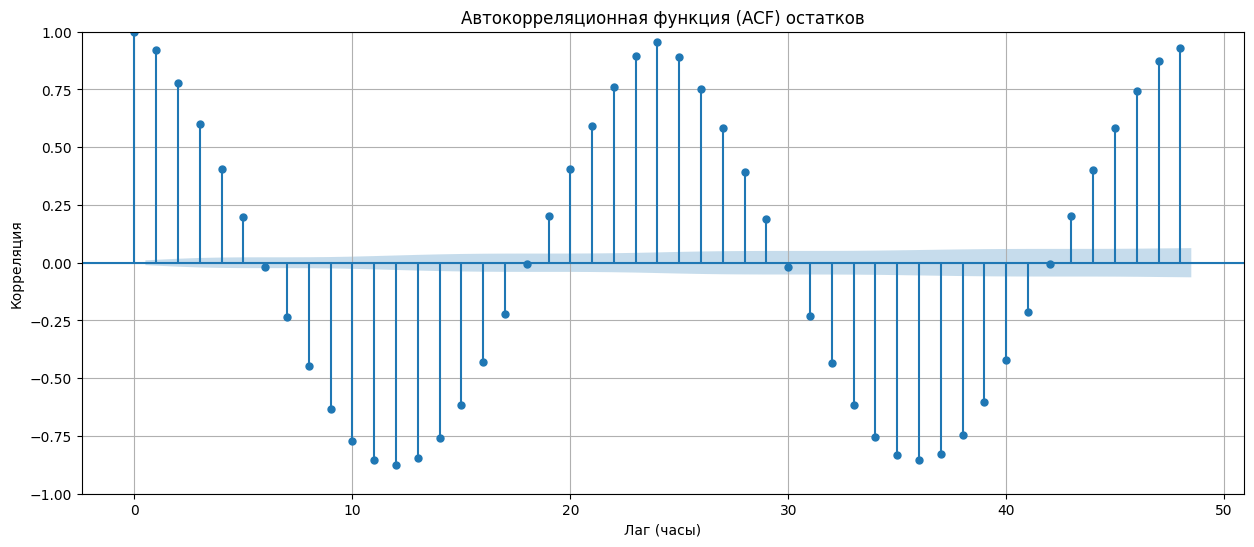

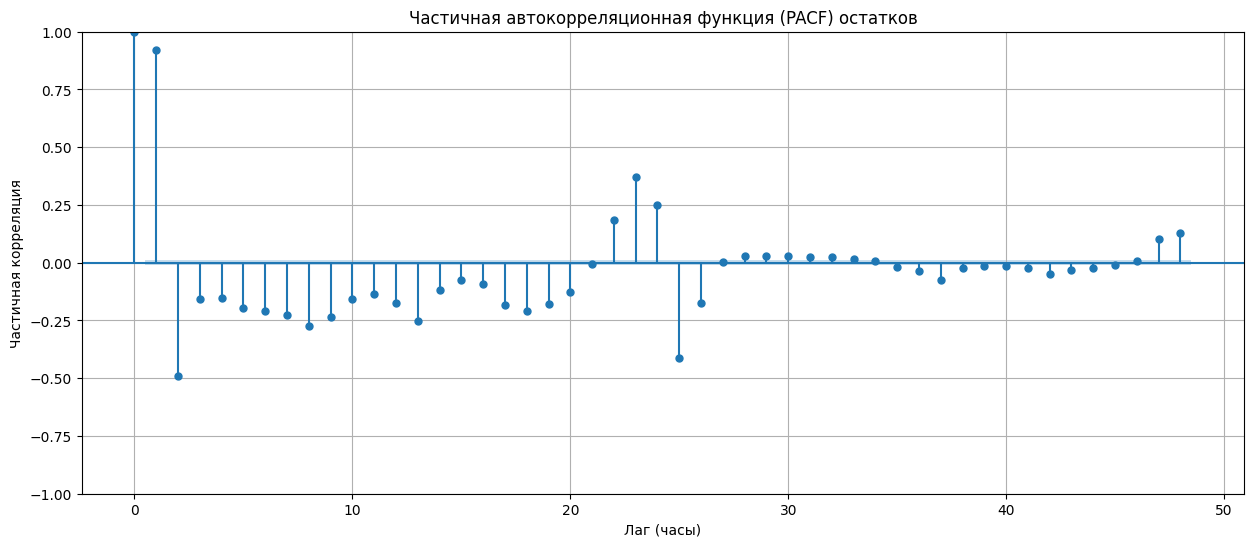

In [ ]:
# 1. Проверка автокорреляции (ACF) — зависимость от прошлых значений
plt.figure(figsize=(15, 6))
plot_acf(decomposed.resid.dropna(), lags=48, ax=plt.gca())  # 48 лагов = 2 суток
plt.title('Автокорреляционная функция (ACF) остатков')
plt.xlabel('Лаг (часы)')
plt.ylabel('Корреляция')
plt.grid(True)
plt.show()

# 2. Проверка частичной автокорреляции (PACF) — прямая зависимость
plt.figure(figsize=(15, 6))
plot_pacf(decomposed.resid.dropna(), lags=48, ax=plt.gca())
plt.title('Частичная автокорреляционная функция (PACF) остатков')
plt.xlabel('Лаг (часы)')
plt.ylabel('Частичная корреляция')
plt.grid(True)
plt.show()

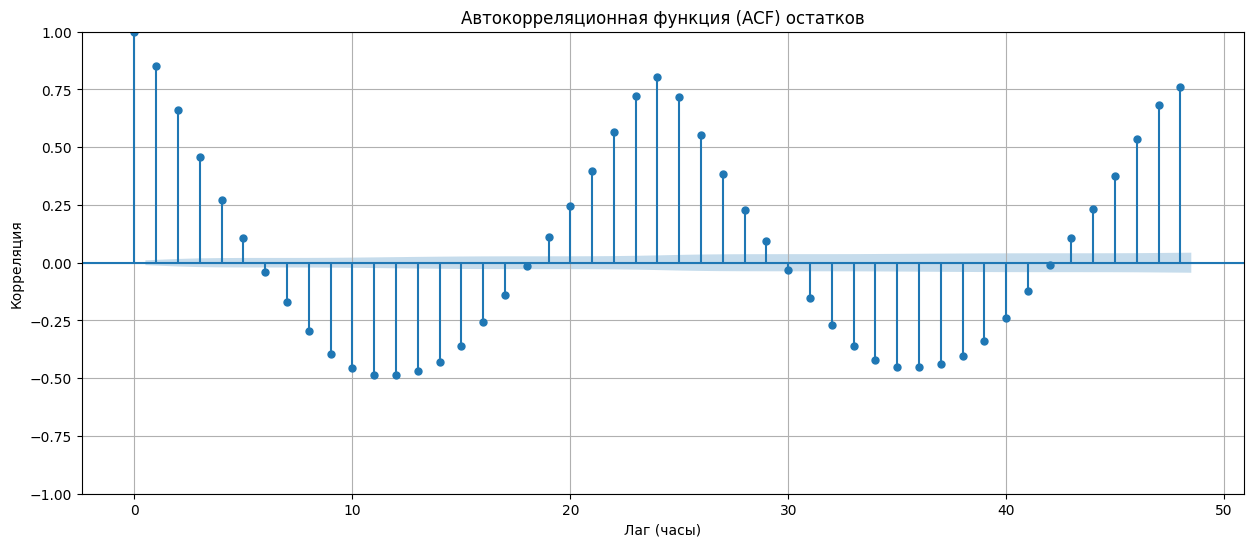

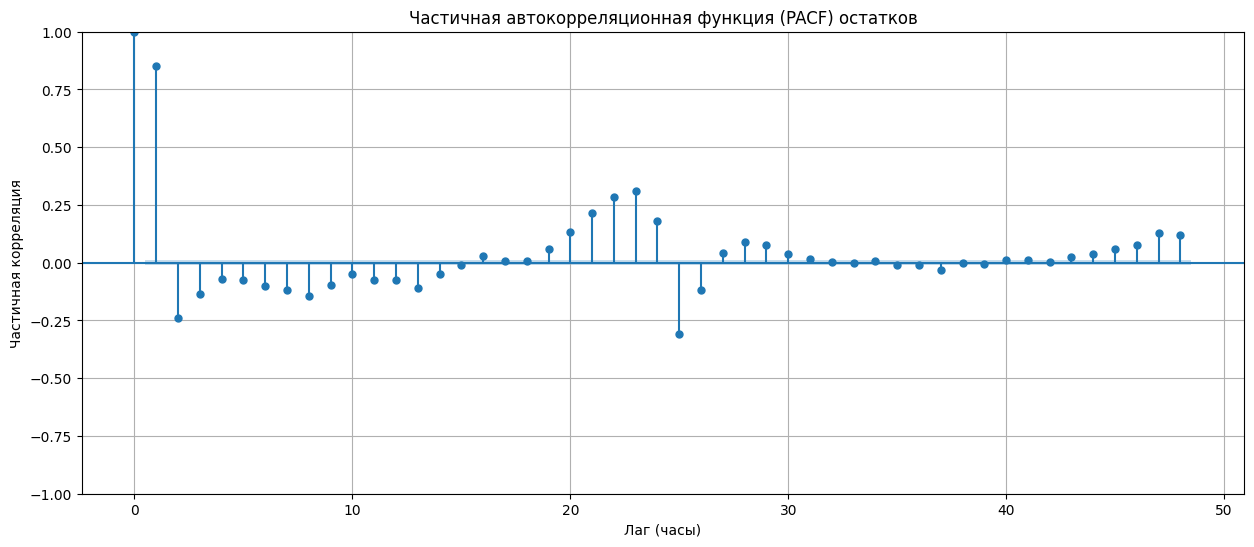

In [ ]:
# 1. Проверка автокорреляции (ACF) — зависимость от прошлых значений
plt.figure(figsize=(15, 6))
plot_acf(decomposed_multi.resid.dropna(), lags=48, ax=plt.gca())  # 48 лагов = 2 суток
plt.title('Автокорреляционная функция (ACF) остатков')
plt.xlabel('Лаг (часы)')
plt.ylabel('Корреляция')
plt.grid(True)
plt.show()

# 2. Проверка частичной автокорреляции (PACF) — прямая зависимость
plt.figure(figsize=(15, 6))
plot_pacf(decomposed_multi.resid.dropna(), lags=48, ax=plt.gca())
plt.title('Частичная автокорреляционная функция (PACF) остатков')
plt.xlabel('Лаг (часы)')
plt.ylabel('Частичная корреляция')
plt.grid(True)
plt.show()

ACF и PACF графики выглядят одинаково для аддитивной и мультипликативной моделей, что ожидаемо, так как показывают структуру зависимости между значениями ряда, а не её масштаб.

Эти два ряда (`resid_add` и `resid_mul`) имеют разные единицы измерения (кВт·ч vs коэффициент), но одинаковую структуру автокорреляции, потому что:

- Если в данных есть суточная периодичность, она останется в остатках обеих моделей;
- Если модель "не докрутила" какой-то паттерн, он проявится в ACF обеих моделей.

То есть визуально графики будут похожи, потому что корреляция — это безразмерная величина (от -1 до 1). Масштаб данных не влияет на форму ACF/PACF.

Также наблюдается волна ACF-графике, что еще раз говорит о дополнительной сезонности, не выявленной ранее при декомпозициях. То есть поведение остатков на графике показывает, что идея с созданием признаков лагов и скользящих потенциально может быть полезной.

### **Выводы**

Задан целевой признак.

Загружен ранее полученный агрегированный датасет, который в результате преобразований стал легче (а значит - и быстрее в работе).

Построение графиков для общего потребления и для общего количества клиентов выявило:
- В начале 2012 года количество клиентов заметно (почти в два раза) увеличилось, что отразилось резким скачком потребления. Также был небольшой прирост количества клиентов в начале 2014.
- Видны переводы часов назад (на летнее время в марте), когда количество и клиентов, и потребленного электричества падает до нуля. А вот аналогичного скачка при переводе вперед в октябре на общем графике не наблюдается.
- Летом тратится гораздо больше электричества (это может быть вполне связано с теплым климатом Португалии). И разница эта сильнее заметна после наплыва клиентов в 2012 году.

В результате декомпозиции временного ряда и изучения графиков автокорреляции остатков для общего потребления электроэнергии:
- Выявилена суточную сезонность;
- Замечена дополнительная сезонность остатков, неучтенная декомпозицией;
- Предполагается, что при сравнении аддитивной и мультипликативной вторая потенциально может лучше описывать поведение ряда.
- Использование в качестве признаков лагов и скользящих потенциально должно пойти на пользу качеству модели



## **Работа с первыми моделями**

Работать я буду с "неспециализированными" моделями. И возьму для будущей работы модели на основе деревьев: часто они справляются лучше линейных (особенно с учетом наличия аномалий), а также не требуют дополнительной обработки данных вроде масштабирования.

Для того, чтобы было удобнее наблюдать все результаты в одном месте, я создам словарь, в который буду добавлять результаты работы моделей.

In [ ]:
# создаем словарь для сравнения
models_dict = {}

Также для того, чтобы качество можели было выше, необходима кросс-валидация. И она должна учитывать особенности работы с временными рядами, чтобы не "заглядывать в будущее" в процессе (данные обучения должеы бвть по временному периоду до данных для предсказания).

In [ ]:
# создадим объект для использования для валидации при переборе гиперпараметров
# этот класс используется для разделения временных рядов на обучающие и тестовые наборы данных
tscv = TimeSeriesSplit(n_splits=3, # количество разделений (сплитов) временных рядов
                  # количество временных шагов между последним обучающим примером и первым тестовым примером в каждом сплите
                       gap=(24 * 7)) # указали промежуток в одну неделю между обучающим и тестовым наборами данных

Также необходимо вабрать метрику, по которой будет происходить поиск лучшей модели. Я выбрала таковой MAE ((Mean Absolute Error). Она обладает полезныи и подходящими под поставленную задачу свойствами, а именно:

- Простота:	считается как среднее абсолютных разниц. Это интуитивно понятно даже не-специалистам.
- Интерпретируемость: показывает ошибку в тех же единицах, что и целевая переменная (кВт·ч). Это легко объяснить бизнесу: "Модель ошибается в среднем на 4 250 кВт·ч".
- Бизнес-метрика:	Ошибка в кВт·ч — это прямые деньги (объём электроэнергии). Для закупок важнее понимать, на сколько кВт·ч мы ошиблись, а не на сколько процентов.
- Устойчивость к выбросам:	в отличие от RMSE, MAE не штрафует сильнее за большие ошибки. Это важно, потому что в данных есть аномалии (переход времени, праздники), но они не должны сильно влиять на оценку модели.

Однако для дополнительной наглядности я буду замерять и некоторые другие метрики моделей.


Что значат используемые далее метрики качества модели (с примерами):


| Метрика | Что это | Как понять | Пример |
| :--- | :--- | :--- | :--- |
| **MAE** (Mean Absolute Error) | Средняя абсолютная ошибка | "В среднем модель ошибается на X кВт·ч".<br>Чем меньше → тем лучше. | MAE = 4 250 кВт·ч → отличный результат (2.17% от среднего) |
| **RMSE** (Root Mean Squared Error) | Среднеквадратичная ошибка | Штрафует за **крупные** ошибки.<br>Если RMSE сильно > MAE → есть редкие, но большие ошибки. | RMSE = 6 350 кВт·ч → ошибки есть, но редкие |
| **R²** (Коэффициент детерминации) | Доля объяснённой дисперсии | Показывает, какую часть изменений модель объясняет.<br>Чем ближе к 1 → тем лучше. | R² = 0.99 → модель объясняет 99% изменений |
| **MAPE** (Mean Absolute Percentage Error) | Средняя абсолютная процентная ошибка | "В среднем ошибка составляет X% от факта".<br>Нужна для относительного сравнения. | MAPE = 5.22% → в среднем ошибка 5.22% от фактического потребления |

### **Подготовка данных**

Для работы с первыми моделями подготовлю данные, создав лаги для обоих агрегированных признаков (хоть потенциально признак количества активных клиентов слаб) и некоторые временные признаки.

In [ ]:
print("="*80)
print(color.BLUE + color.BOLD + f"ПОДГОТОВКА ДАННЫХ ДЛЯ ПЕРВЫХ МОДЕЛЕЙ" + color.END)
print("="*80)

# Создаем копию для работы
df_model = df_two_features.copy()

# У нас есть df_model с признаками:
# - active_clients
# - total_consumption_lag_24 (суточный лаг)
# Таргет: total_consumption

# ----- 1. ДОБАВЛЯЕМ ВРЕМЕННЫЕ ПРИЗНАКИ (до лагов!) -----
df_model['hour'] = df_model.index.hour
df_model['day_of_week'] = df_model.index.dayofweek
df_model['month'] = df_model.index.month
df_model['day_of_year'] = df_model.index.dayofyear
df_model['is_weekend'] = (df_model.index.dayofweek >= 5).astype(int)

# ----- 2. СОЗДАЕМ ЛАГИ ДЛЯ ОБОИХ ПРИЗНАКОВ -----

# Лаги для total_consumption
for lag in [1, 2, 3, 24, 48, 168]:  # 1ч, 2ч, 3ч, сутки, 2 суток, неделя
    df_model[f'total_consumption_lag_{lag}'] = df_model['total_consumption'].shift(lag)

# Лаги для active_clients
for lag in [1, 2, 3, 24, 48, 168]:
    df_model[f'active_clients_lag_{lag}'] = df_model['active_clients'].shift(lag)

# Удаляем строки с NaN (первые 168 часов)
df_model = df_model.dropna()

print(f"- Размер df_model после добавления лагов: {df_model.shape[0]} строк × {df_model.shape[1]} столбцов\n")

print(color.BLUE + color.BOLD + f"\n Первые 5 строк:" + color.END)
display(df_model.head())
print(color.BLUE + color.BOLD + f"\n Информация о датафрейме:" + color.END)
display(df_model.info())

ПОДГОТОВКА ДАННЫХ ДЛЯ ПЕРВЫХ МОДЕЛЕЙ
- Размер df_model после добавления лагов: 34897 строк × 19 столбцов


 Первые 5 строк:


,total_consumption,active_clients,hour,day_of_week,month,day_of_year,is_weekend,total_consumption_lag_1,total_consumption_lag_2,total_consumption_lag_3,total_consumption_lag_24,total_consumption_lag_48,total_consumption_lag_168,active_clients_lag_1,active_clients_lag_2,active_clients_lag_3,active_clients_lag_24,active_clients_lag_48,active_clients_lag_168
timestamp,,,,,,,,,,,,,,,,,,,
2011-01-08 00:00:00,"86,403.30",158,0,5,1,8,1,"111,609.59","130,176.98","141,034.49","85,716.81","85,490.07","51,764.57",156.00,156.00,156.00,157.00,157.00,158.00
2011-01-08 01:00:00,"72,534.98",158,1,5,1,8,1,"86,403.30","111,609.59","130,176.98","73,297.91","72,602.27","66,344.63",158.00,156.00,156.00,157.00,156.00,158.00
2011-01-08 02:00:00,"69,325.03",158,2,5,1,8,1,"72,534.98","86,403.30","111,609.59","70,543.53","69,897.63","65,981.05",158.00,158.00,156.00,157.00,156.00,158.00
2011-01-08 03:00:00,"68,554.18",158,3,5,1,8,1,"69,325.03","72,534.98","86,403.30","70,242.04","69,467.26","66,576.53",158.00,158.00,158.00,157.00,156.00,158.00
2011-01-08 04:00:00,"69,033.52",158,4,5,1,8,1,"68,554.18","69,325.03","72,534.98","68,884.02","69,493.36","64,963.55",158.00,158.00,158.00,157.00,156.00,158.00



 Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34897 entries, 2011-01-08 00:00:00 to 2015-01-01 00:00:00
Freq: h
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   total_consumption          34897 non-null  float64
 1   active_clients             34897 non-null  int64  
 2   hour                       34897 non-null  int32  
 3   day_of_week                34897 non-null  int32  
 4   month                      34897 non-null  int32  
 5   day_of_year                34897 non-null  int32  
 6   is_weekend                 34897 non-null  int64  
 7   total_consumption_lag_1    34897 non-null  float64
 8   total_consumption_lag_2    34897 non-null  float64
 9   total_consumption_lag_3    34897 non-null  float64
 10  total_consumption_lag_24   34897 non-null  float64
 11  total_consumption_lag_48   34897 non-null  float64
 12  total_consumption_lag_168  34897

None

Датасет подготовлен, теперь можно переходить к обучению моделей.

### **Разбиение**

Перед неспосредственным обучением модели необходимо разбить данные на тренировочные и тестовые. Так как данные представляют собой временной ряд, перемешивать их (как это делалось бы в "обычных" данных) нельзя (это нарушит последовательность данных).

Также обычное разбиение по долям не слишком применимо к временным рядам. Более практично разбить их на конкретные временные периоды как для лучшего обучения, так и наглядности результатов.

In [ ]:
# ----- 3. РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ (2011–2013 — обучение, 2014-2015 — тест)" + color.END)
print("="*80)

# Разделение по времени (2011–2013 — обучение, 2014-2015 — тест)
train_mask = df_model.index.year < 2014
test_mask = df_model.index.year >= 2014

X_train = df_model[train_mask].drop(target, axis=1)
y_train = df_model[train_mask][target]

X_test = df_model[test_mask].drop(target, axis=1)
y_test = df_model[test_mask][target]

print(f"- Обучающая выборка: {X_train.shape[0]} строк ({X_train.index.min()} — {X_train.index.max()})")
print(f"- Тестовая выборка: {X_test.shape[0]} строк ({X_test.index.min()} — {X_test.index.max()})")


РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ (2011–2013 — обучение, 2014-2015 — тест)
- Обучающая выборка: 26136 строк (2011-01-08 00:00:00 — 2013-12-31 23:00:00)
- Тестовая выборка: 8761 строк (2014-01-01 00:00:00 — 2015-01-01 00:00:00)


### **Обучение**

Как я уже упоминала, использовать я буду "неспециализированные" модели, основанные на деревьях решений. Одиночное дерево - как базовую модель, и Случайный лес - совокупность деревьев с бэггингом, XGBoost - совокупность деревьев с бустингом. Таблица ниже является обоснованием выбора данного набора моделей.


Краткое сравнение трёх моделей:

|Модель|Как работает|Плюсы|Минусы|
|------|------------|-----|------|
|Decision Tree (Одиночное дерево)|Последовательно делит данные по признакам,<br> как дерево с ветками|+ Простая и понятная <br>+ Быстро обучается<br>+ Легко интерпретировать|- Может сильно переобучаться<br>- Чувствительна к шуму<br>- Низкая точность на сложных данных|
|Random Forest (Случайный лес)|Строит много деревьев<br>на разных подвыборках данных (бэггинг) <br>и усредняет их предсказания|+ Точнее одного дерева<br>+ Меньше переобучается<br>+ Устойчив к выбросам|- Тяжелее интерпретировать<br>- Дольше обучается<br>- Требует больше памяти|
|XGBoost (Градиентный бустинг)|Строит деревья последовательно.<br>Каждое новое дерево исправляет<br>ошибки предыдущего (бустинг)|<br>+ Часто высочайшая точность<br>+ Работает с пропусками<br>+ Обычно быстрее RandomForest<br>+ Часто побеждает в соревнованиях|<br> - Самая сложная для понимания<br>- Требует настройки параметров<br>- Может переобучаться<br>- Чувствительна к выбросам|

Пока буду использовать сплошной перебор гиперпараметров (чтобы рассмотреть больше вариантов, чем при случайном переборе, но не упустить какой-либо оптимум, как может быть при использовании оптуны) и небольшой их набор для перебора (для ускорения процесса).

#### **Дерево решений**

Начну с одиночного дерева решений в качестве будущей базовой модели с которой буду сравнивать результаты всех остальных.

In [ ]:
# функция с моделью Дерева решений
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Decision_Tree_Regressor(X_train, y_train):

    # инициализация модели
    model = DecisionTreeRegressor(random_state=RANDOM_STATE)

    # Определение сетки гиперпараметров
    param_grid = {
        # максимальная глубина дерева
        'max_depth': [10, 15, 20],
        # минимальное число объектов, при котором они делятся на "ветви"
        'min_samples_split': [5, 10, 15, 20],
        # максимальное количество признаков, которые рассматриваются при поиске лучшего разделения
        'max_features': [None, 'log2', 'sqrt']
    }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model,
        param_grid,
        scoring='neg_mean_absolute_error',  # MAE!
        refit=True,
        n_jobs=-1,
        cv=tscv,
        verbose=1
    )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_mae = -grid_search.best_score_
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее MAE при обучении: " \
          + color.END + f"{best_mae:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: " \
          + color.END + f"{grid_search.best_params_}\n")

    return {
        'model': best_model,
        'best_mae': best_mae,
        'best_params': best_params,
    }

In [ ]:
# тренируем модель
# вызов функции и сохранение результатов
%time result_dtr = Decision_Tree_Regressor(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшее MAE при обучении: 16304.5009
Лучшие параметры: {'max_depth': 10, 'max_features': None, 'min_samples_split': 5}

CPU times: user 1.11 s, sys: 119 ms, total: 1.23 s
Wall time: 18.6 s


In [ ]:
# добавляем в словарь
models_dict['DTR'] = {
    # Для настройки параметров (внутренний критерий)
    'MAE_CV': round(result_dtr['best_mae'], 4),

    # ГЛАВНЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ (внешний критерий)
    'MAE_test': round(mean_absolute_error(y_test, result_dtr['model'].predict(X_test)), 4),
    'RMSE_test': round(np.sqrt(mean_squared_error(y_test, result_dtr['model'].predict(X_test))), 4),
    'R2_test': round(r2_score(y_test, result_dtr['model'].predict(X_test)), 4),
    'MAPE_test': round(np.mean(np.abs((y_test - result_dtr['model'].predict(X_test)) / y_test)) * 100, 2),

    'params': result_dtr['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"


#### **Случайный лес**

In [ ]:
# функция с моделью леса случайных деревьев
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Random_Forest_Regressor(X_train, y_train):

    # инициализация модели
    model = RandomForestRegressor(random_state=RANDOM_STATE)

    # Определение сетки гиперпараметров
    param_grid = {
        # максимальная глубина дерева
        'max_depth': [10, 15],

        # количество деревьев
        'n_estimators': [50, 150, 200],

        # минимальное число объектов для разделения узла
        'min_samples_split': [10, 15],

        # минимальное число объектов в листе
        'min_samples_leaf': [4, 6],

        # максимальное количество признаков для поиска лучшего разделения
        'max_features': [None, 'sqrt', 'log2']
    }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model,  # модель
        param_grid,  # параметры
        scoring='neg_mean_absolute_error',  # метрика (MAE)
        refit=True,  # переобучить лучшую модель на всех данных
        n_jobs=-1,  # все ядра
        cv=tscv,  # кросс-валидация с ранее заданными параметрами
        verbose=1  # не отключаем вывод
    )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_mae = -grid_search.best_score_  # т.к. scoring="neg_mean_absolute_error"
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее MAE при обучении: " \
          + color.END + f"{best_mae:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: " \
          + color.END + f"{grid_search.best_params_}\n")

    # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_mae': best_mae,
        'best_params': best_params
    }

In [ ]:
# тренируем модель
# вызов функции и сохранение результатов
%time result_rf = Random_Forest_Regressor(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшее MAE при обучении: 14066.3430
Лучшие параметры: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}

CPU times: user 1min 19s, sys: 1.78 s, total: 1min 21s
Wall time: 27min 33s


In [ ]:
# добавляем в словарь
models_dict['RandomForest'] = {
    # Для настройки параметров (внутренний критерий)
    'MAE_CV': round(result_rf['best_mae'], 4),

    # ГЛАВНЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ (внешний критерий)
    'MAE_test': round(mean_absolute_error(y_test, result_rf['model'].predict(X_test)), 4),
    'RMSE_test': round(np.sqrt(mean_squared_error(y_test, result_rf['model'].predict(X_test))), 4),
    'R2_test': round(r2_score(y_test, result_rf['model'].predict(X_test)), 4),
    'MAPE_test': round(np.mean(np.abs((y_test - result_rf['model'].predict(X_test)) / y_test)) * 100, 2),

    'params': result_rf['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"
RandomForest,"14,066.34","4,794.42","8,030.33",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"


Случайный лес ожидаемо показывает лучшие результаты по абсолютной метрике относительно одиночного дерева.

#### **XGBoost**

In [ ]:
# функция с моделью XGBoost
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def XGBoost_Regressor(X_train, y_train):

    # инициализация модели
    model = xgb.XGBRegressor(
        random_state=RANDOM_STATE,
        eval_metric='mae'
    )

    # Определение сетки гиперпараметров
    param_grid = {
        # количество деревьев
        'n_estimators': [100, 200, 300],
        # максимальная глубина дерева
        'max_depth': [4, 6, 8],
        # скорость обучения
        'learning_rate': [0.01, 0.05, 0.1],
        # доля объектов для обучения каждого дерева
        'subsample': [0.8, 1.0],
        # доля признаков для обучения каждого дерева
        'colsample_bytree': [0.8, 1.0]
    }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model,  # модель
        param_grid,  # параметры
        scoring='neg_mean_absolute_error',  # метрика (MAE)
        refit=True,  # переобучить лучшую модель на всех данных
        n_jobs=-1,  # все ядра
        cv=tscv,  # кросс-валидация с ранее заданными параметрами
        verbose=1  # не отключаем вывод
    )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_mae = -grid_search.best_score_  # т.к. scoring="neg_mean_absolute_error"
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее MAE при обучении: " \
          + color.END + f"{best_mae:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: " \
          + color.END + f"{grid_search.best_params_}\n")

    # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_mae': best_mae,
        'best_params': best_params
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_xgb = XGBoost_Regressor(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Лучшее MAE при обучении: 14526.4250
Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

CPU times: user 4.36 s, sys: 730 ms, total: 5.09 s
Wall time: 4min 51s


In [ ]:
# добавляем в словарь
models_dict['XGBoost'] = {
    # Для настройки параметров (внутренний критерий)
    'MAE_CV': round(result_xgb['best_mae'], 4),

    # ГЛАВНЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ (внешний критерий)
    'MAE_test': round(mean_absolute_error(y_test, result_xgb['model'].predict(X_test)), 4),
    'RMSE_test': round(np.sqrt(mean_squared_error(y_test, result_xgb['model'].predict(X_test))), 4),
    'R2_test': round(r2_score(y_test, result_xgb['model'].predict(X_test)), 4),
    'MAPE_test': round(np.mean(np.abs((y_test - result_xgb['model'].predict(X_test)) / y_test)) * 100, 2),

    'params': result_xgb['best_params']
}

Теперь, когда три первых модели обучены, необходимо выбрать и проанализировать лучшую из них.

### **Лучшая модель**

#### **Выбор лучшей модели**

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"
RandomForest,"14,066.34","4,794.42","8,030.33",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost,"14,526.42","6,670.57","9,369.05",0.99,3.61,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}"


У всех моделей хорошая объясняющая способность. Также у всех моделей метрики на тесте лучше, чем при обучении, что также указывает на хорошую обобщающую способность и объясняется тем, что данные в обучаюших данных обладали большей волативностью (был резкий прирост клиентов и потребления в 2012 году). Модели не переобучились.

Случайный лес показывает лучший результат по абсолютным ошибкам как на кросс-валидации, так и на тесте. Но при этом имеет самую высокую MAPE, что можно объяснить тем, что MAPE считает ошибку в процентах от фактического значения, из чего следует:

- Если у нас есть маленькие значения (например, ночью), даже небольшая абсолютная ошибка превращается в огромный процент.
- RandomForest, возможно, чуть хуже предсказывает ночные часы (где значения малы), из-за чего MAPE взлетает.
- DTR и XGBoost ошибаются на этих же ночных значениях меньше в процентах, хотя в абсолютных цифрах их ошибка больше.

Ввиду того что RandomForest показывает лучший результат по абсолютной ошибке (MAE_test = 4 794 кВт·ч), это делает его лучшей моделью с точки зрения бизнеса, так как минимизирует ошибку в кВт·ч (объём электроэнергии).

#### **Анализ моделей**

Проанализирую признанную лучшей модель, чтобы получить некоторые инсайды для потенциального улучшения, а также более наглядно рассмотреть качество ее работы.


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ RANDOMFOREST


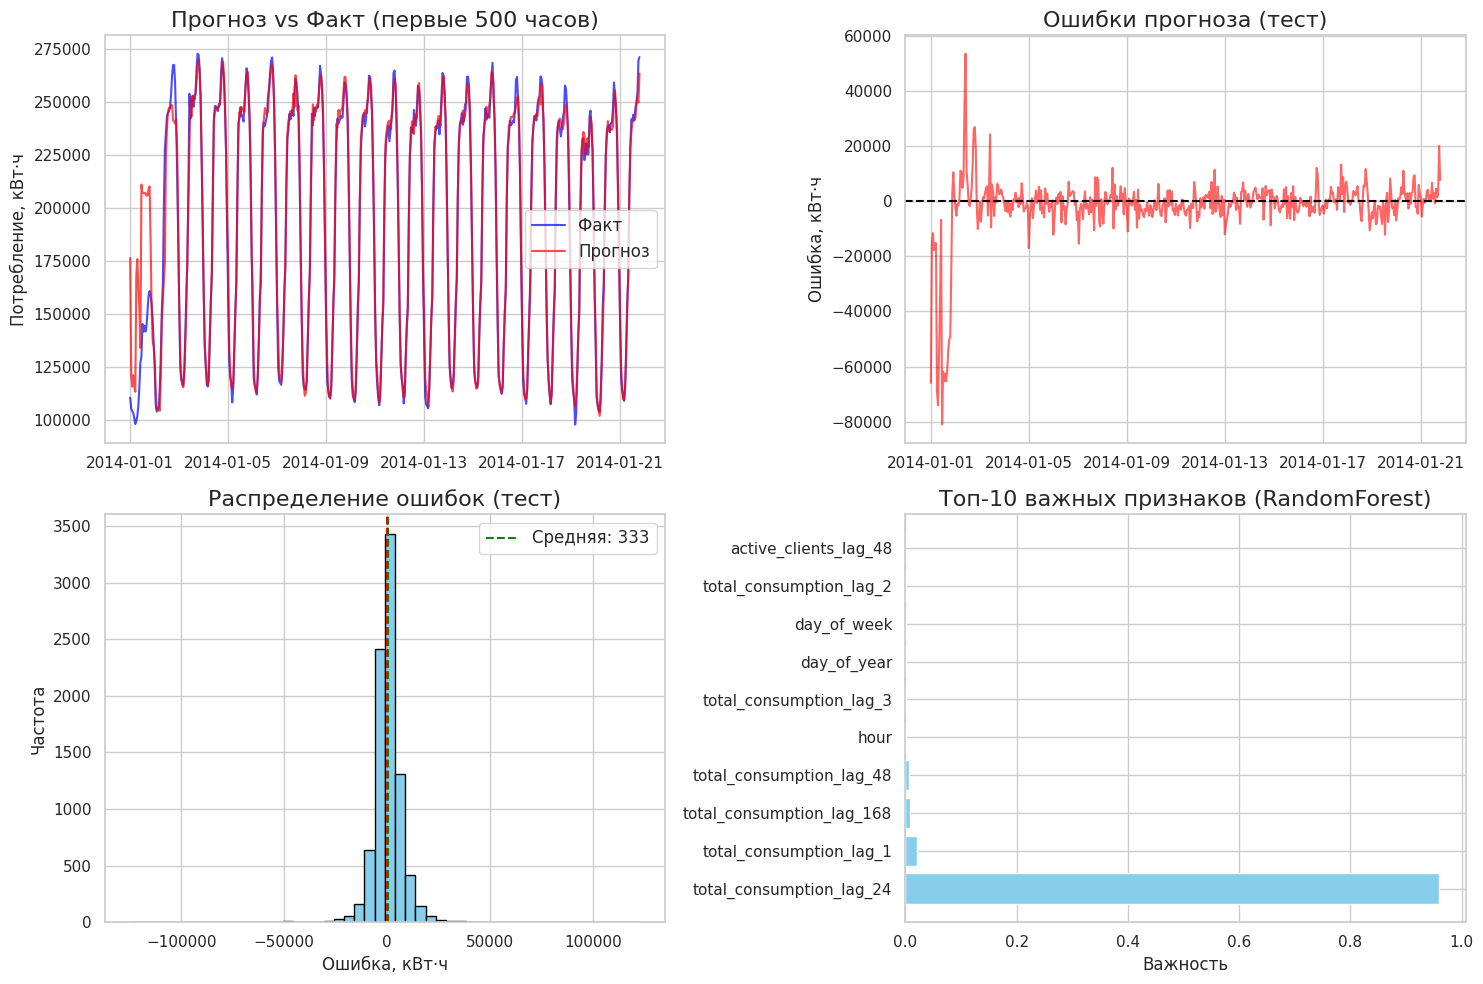

<Figure size 1200x600 with 0 Axes>

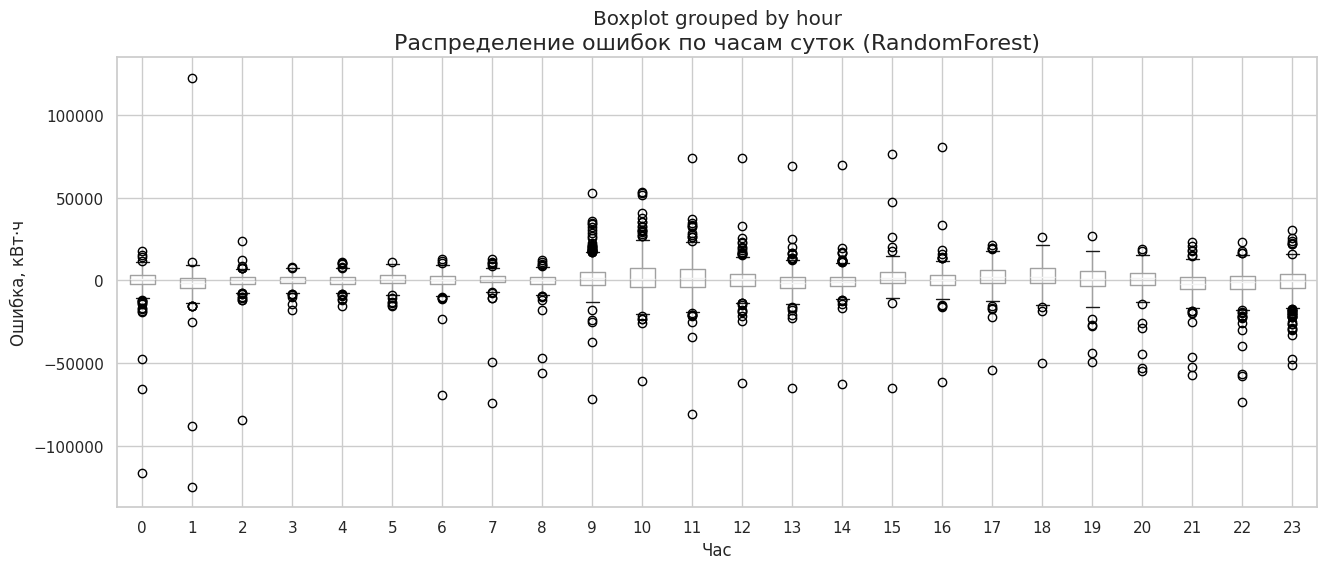


- Статистика ошибок по часам:
      count      mean       std         min       25%       50%      75%  \
hour                                                                       
0    366.00   -223.27  9,010.16 -116,585.82 -2,424.07    878.73 3,254.65   
1    365.00 -1,870.60 11,268.96 -124,780.14 -4,742.91 -1,360.35 1,646.06   
2    365.00   -337.03  5,600.01  -84,475.79 -1,850.10   -105.13 1,837.46   
3    365.00      6.53  3,349.45  -17,759.50 -1,839.27    331.78 1,989.90   
4    365.00   -290.09  3,483.41  -15,212.72 -2,079.39    -71.70 1,831.48   
5    365.00    403.59  3,959.85  -15,245.61 -1,648.40    602.87 2,991.70   
6    365.00   -226.88  5,382.20  -69,095.65 -2,370.03     43.66 2,511.19   
7    365.00    398.91  5,645.76  -74,032.95 -1,079.07    698.06 2,775.46   
8    365.00   -214.15  5,364.70  -55,810.37 -2,331.13    157.81 2,048.35   
9    365.00  2,232.72  9,869.50  -71,438.90 -2,478.18  1,177.41 5,359.46   
10   365.00  2,764.49 12,031.19  -60,600.55 -3,996.26    

In [ ]:
# ----- ВИЗУАЛИЗАЦИЯ ДЛЯ RANDOMFOREST (ЛУЧШАЯ МОДЕЛЬ) -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ RANDOMFOREST" + color.END)
print("="*80)

# берем лучшую модель
best_model = result_rf['model']

# предсказания
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# ----- 1. ГРАФИКИ -----
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1.1 Прогноз vs факт
test_subset = 500
axes[0, 0].plot(y_test.index[:test_subset], y_test.values[:test_subset],
                label='Факт', color='blue', alpha=0.7)
axes[0, 0].plot(y_test.index[:test_subset], y_pred_test[:test_subset],
                label='Прогноз', color='red', alpha=0.7)
axes[0, 0].set_title('Прогноз vs Факт (первые 500 часов)')
axes[0, 0].set_ylabel('Потребление, кВт·ч')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 1.2 Ошибки прогноза
errors_test = y_test.values - y_pred_test
axes[0, 1].plot(y_test.index[:test_subset], errors_test[:test_subset],
                color='red', alpha=0.6)
axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].set_title('Ошибки прогноза (тест)')
axes[0, 1].set_ylabel('Ошибка, кВт·ч')
axes[0, 1].grid(True)

# 1.3 Распределение ошибок
axes[1, 0].hist(errors_test, bins=50, color='skyblue', edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--')
axes[1, 0].axvline(x=np.mean(errors_test), color='green', linestyle='--',
                   label=f'Средняя: {np.mean(errors_test):.0f}')
axes[1, 0].set_title('Распределение ошибок (тест)')
axes[1, 0].set_xlabel('Ошибка, кВт·ч')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 1.4 Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(10)
axes[1, 1].barh(top_features['feature'], top_features['importance'], color='skyblue')
axes[1, 1].set_title('Топ-10 важных признаков (RandomForest)')
axes[1, 1].set_xlabel('Важность')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# ----- 2. ОШИБКИ ПО ЧАСАМ -----

errors_by_hour = pd.DataFrame({
    'hour': y_test.index.hour,
    'error': errors_test
})

plt.figure(figsize=(12, 6))
errors_by_hour.boxplot(by='hour', figsize=(15, 6))
plt.title('Распределение ошибок по часам суток (RandomForest)')
plt.xlabel('Час')
plt.ylabel('Ошибка, кВт·ч')
plt.grid(True)
plt.show()

print("\n- Статистика ошибок по часам:")
print(errors_by_hour.groupby('hour')['error'].describe())

# ----- 3. ТОП-20 ВАЖНЫХ ПРИЗНАКОВ -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ТОП-20 ВАЖНЫХ ПРИЗНАКОВ (RandomForest)" + color.END)
print("="*80)
print(feature_importance.head(20).to_string(index=False))

print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"ГОТОВО!" + color.END)
print("="*80)

Модель в основном ошибается в первые пару дней (самые большие ошибки - первые дни), затем же предсказанные объемы достаточно близки к реальным. Возможно дело в том, что первыми днями периода оказались праздичными (Новый год и Рождество). которые могут приводить к повышению потребления, в то время как модель могла считать эти дни обычными.

На это указывает в том числе и важность признаков: модель в основном опирается на лаги (сутки назад, час назад, неделя и два дня назад). Причем почти всю важность на себя забирает суточный лаг. А сведений о поведении потребления год назад у модели в принципе нет ввиду отсутствия такого признака.

При наблюднии за mean в Статистике ошибок по часам можно заметить, что ошибки имеют систематический характер:

- Утром (9-10) и вечером (18-19) модель завышает.
- Ночью (1-2) и поздним вечером (21-22) модель занижает.

Это говорит о том, что модель не до конца уловила суточный паттерн и добавление большего количества лагов либо скользящих средних модет улучшить ее качество.

Также видна большая ошибка в час ночи, что связано с аномалией, вызываемой переводом часов назад и удвоением потребления (модель считает этот час также "обычным").

В целом, модель показывает хорошее качество и может использоваться для дальнейшего прогнозирования с учетом имеющихся особенностей (проблемы с предсказанием в новогодний период и во время переходя на летнее/зимнее время).

Дополнительно взгляну на аналогичные графики для XGBoost для дополнительного визуального сравнения их поведения и качества.


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ XGBoost


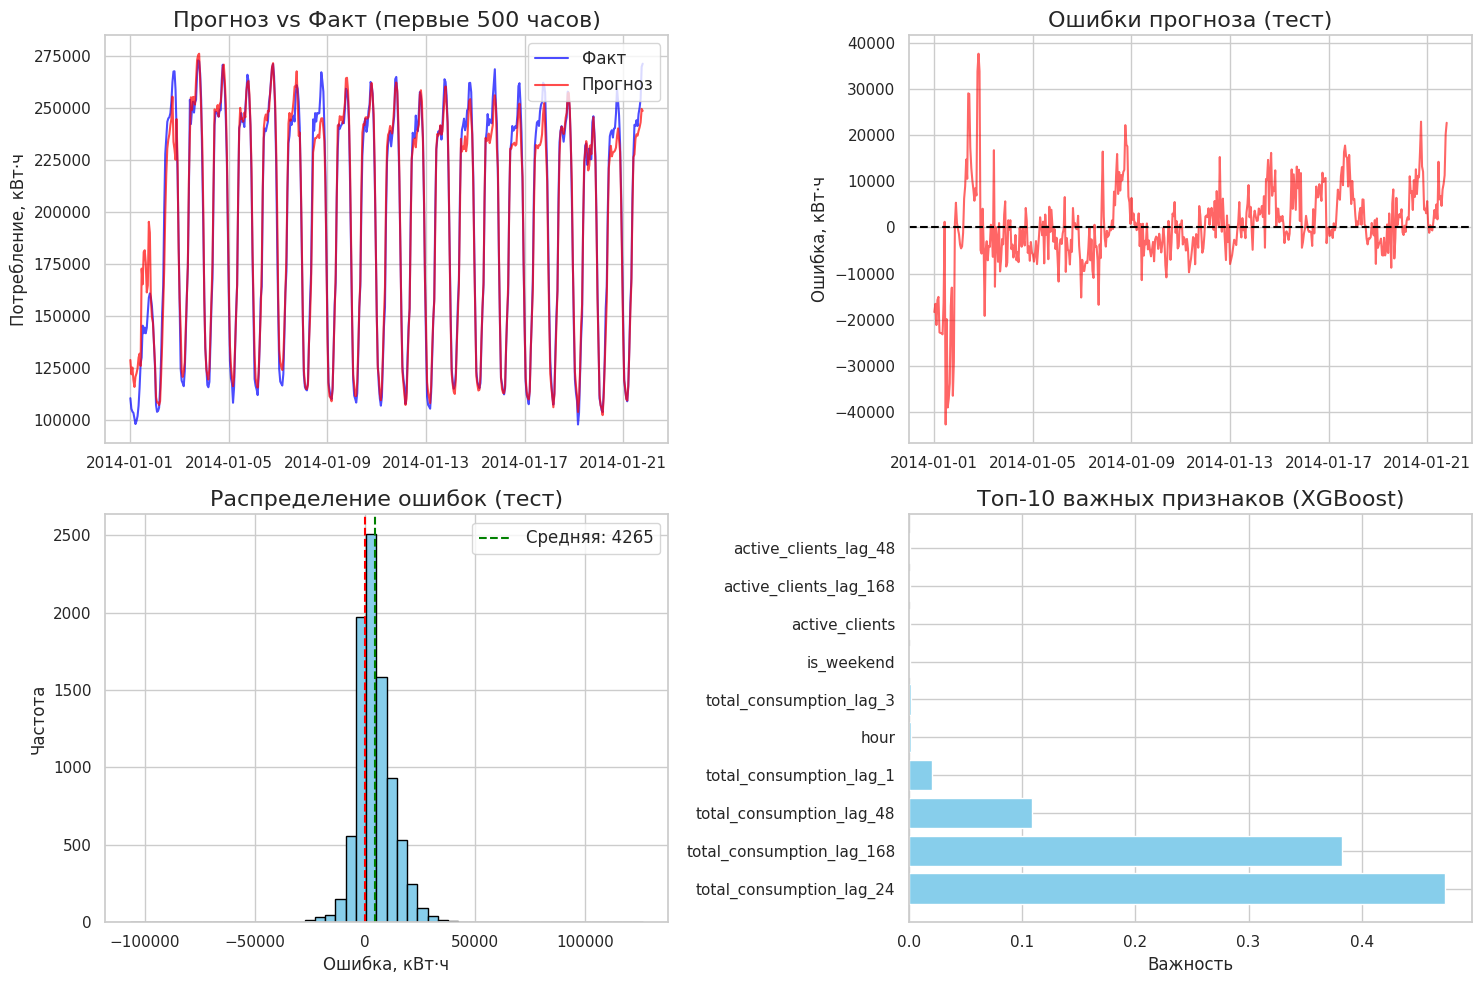

<Figure size 1200x600 with 0 Axes>

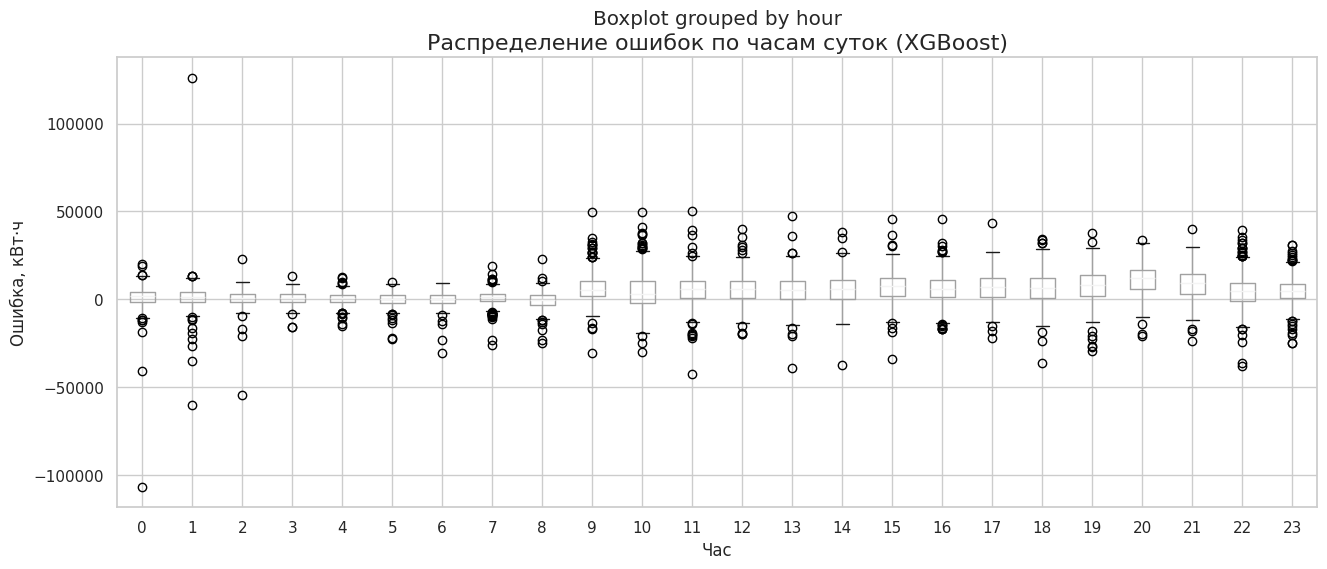


- Статистика ошибок по часам:
      count      mean       std         min       25%       50%       75%  \
hour                                                                        
0    366.00  1,193.85  7,944.34 -106,694.72 -1,574.06  1,729.18  4,400.03   
1    365.00  1,393.16  8,954.21  -60,225.53 -1,425.71  1,406.22  4,129.31   
2    365.00    446.36  4,829.64  -54,243.52 -1,781.70    630.38  2,980.36   
3    365.00    760.24  3,568.55  -15,728.06 -1,475.18    901.06  3,127.92   
4    365.00    299.12  3,618.32  -15,050.54 -1,621.02    515.60  2,359.10   
5    365.00    124.24  3,871.99  -22,742.71 -1,858.32    317.78  2,345.79   
6    365.00    300.93  3,983.47  -30,328.12 -1,808.67    285.67  2,608.38   
7    365.00    782.98  4,314.12  -26,142.96 -1,024.30  1,082.91  3,024.18   
8    365.00   -492.23  4,869.88  -24,708.97 -3,191.88   -268.30  2,247.27   
9    365.00  6,675.82  8,742.04  -30,584.48  1,636.52  5,523.03 10,534.23   
10   365.00  4,632.25 10,939.77  -29,929.11 -

In [ ]:
# ----- ВИЗУАЛИЗАЦИЯ ДЛЯ XGBoost -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ XGBoost" + color.END)
print("="*80)

# берем лучшую модель
best_model = result_xgb['model']

# предсказания
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# ----- 1. ГРАФИКИ -----
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1.1 Прогноз vs факт
test_subset = 500
axes[0, 0].plot(y_test.index[:test_subset], y_test.values[:test_subset],
                label='Факт', color='blue', alpha=0.7)
axes[0, 0].plot(y_test.index[:test_subset], y_pred_test[:test_subset],
                label='Прогноз', color='red', alpha=0.7)
axes[0, 0].set_title('Прогноз vs Факт (первые 500 часов)')
axes[0, 0].set_ylabel('Потребление, кВт·ч')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 1.2 Ошибки прогноза
errors_test = y_test.values - y_pred_test
axes[0, 1].plot(y_test.index[:test_subset], errors_test[:test_subset],
                color='red', alpha=0.6)
axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].set_title('Ошибки прогноза (тест)')
axes[0, 1].set_ylabel('Ошибка, кВт·ч')
axes[0, 1].grid(True)

# 1.3 Распределение ошибок
axes[1, 0].hist(errors_test, bins=50, color='skyblue', edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--')
axes[1, 0].axvline(x=np.mean(errors_test), color='green', linestyle='--',
                   label=f'Средняя: {np.mean(errors_test):.0f}')
axes[1, 0].set_title('Распределение ошибок (тест)')
axes[1, 0].set_xlabel('Ошибка, кВт·ч')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 1.4 Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(10)
axes[1, 1].barh(top_features['feature'], top_features['importance'], color='skyblue')
axes[1, 1].set_title('Топ-10 важных признаков (XGBoost)')
axes[1, 1].set_xlabel('Важность')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# ----- 2. ОШИБКИ ПО ЧАСАМ -----

errors_by_hour = pd.DataFrame({
    'hour': y_test.index.hour,
    'error': errors_test
})

plt.figure(figsize=(12, 6))
errors_by_hour.boxplot(by='hour', figsize=(15, 6))
plt.title('Распределение ошибок по часам суток (XGBoost)')
plt.xlabel('Час')
plt.ylabel('Ошибка, кВт·ч')
plt.grid(True)
plt.show()

print("\n- Статистика ошибок по часам:")
print(errors_by_hour.groupby('hour')['error'].describe())

# ----- 3. ТОП-20 ВАЖНЫХ ПРИЗНАКОВ -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ТОП-20 ВАЖНЫХ ПРИЗНАКОВ (XGBoost)" + color.END)
print("="*80)
print(feature_importance.head(20).to_string(index=False))

print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"ГОТОВО!" + color.END)
print("="*80)

Поведение модели XGBoost на графиках схоже (максимумы в начале года), но исходя из средних ошибок модель склонна в целом завышать показатели (и также имеет максимум при переводе на летнее/зимнее время).

Касательно же важности признаков XGBoost также опирается на лаги, но уже не отдает столь явное предпочтение лишь одному признаку. Так что данная модель хоть и уступила Случайному лесу сейчас, но также имеет потенциал роста. Поэтому попробую обучить и его тоже заново.

Лаги для активных клиентов ожидаемо не имели важности ни в одной из двух моделей, поэтому исключу их в будущих моделях.

### **Выводы**

Мною были подготовлены данные для обучения моделей, которые включали в качестве признаков:
- лаги для общего потребления и количества активных клинтов;
- временные признаки (например, день недели).

Затем обучено три модели на основе деревьев:
- Decision Tree;
- RandomForest;
- XGBoost.

Метрикой для обучения была выбрана MAE как подходящая по различным критериям бизнес-метрика (устойчива к аномалиям, абсолютность измерения, понятность интерпритации).

Все модели идеально улавливают глобальный тренд (утром — рост, вечером — пик, ночью — спад) и рост потребления за 5 лет. Это общая картина, и все модели с ней справляются «на отлично».

Модель RandomForest показала лучшую точность в абсолютных величинах (MAE = 4 794 кВт·ч), что делает её оптимальной для бизнес-задач, где важна ошибка в объёме электроэнергии. Высокий MAPE объясняется особенностью метрики, а не недостатком модели. Модель не переобучена и потенциально готова к внедрению, однако также имеет и потенциал к улучшению.

Данная модель опирается на лаги потребления, наибольшую важность из которых получил суточный (0.96), сама модель делает максимальные ошибки в первые часы нового года, а также во время перевода часов назад.

Также модель сколонна как к завышению (утром и вечером), так и к занижению (ночью и поздним вечером) предсказываемых результатов.

Так как RandomForest и исследованный дополнительно XGBoost оба имеют потенциал роста, то попробую улучшить их обучив заново с новыми признаками.

Лаги по количеству активных клиентов не привнесли вклада в важность признаков в обе рассмотренные модели поэтому будут исключены из следующих попыток.

## **Работа для улучшения моделей**

Поработаю с признаками и еще раз обучу модели.

Для обучения возьму тот же набор модлей и те же функции их обучения для более честного сравнения, иначе будет сложно понять, от чего изменилось качество: от изменения модели, сетки гиперпараметров, или набора признаков. Разбивку на выборки также буду проводить по той же временной границе.

### **Подготовка данных**

Создам новый датасет на основе ранее наблюдаемой информации.

В нем уже не будет лагов для клиентов (так как модели их не учитывают, что логично из-за их разнородности), но зато добавлю скользящие средние и еще несколько временных признаков. Уменьшать или увеличивать "глубину" лагов я также не буду, чтобы не изменить размер выборки (для той же честности сравнения).

In [ ]:
print("="*80)
print(color.BLUE + color.BOLD + f"ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ" + color.END)
print("="*80)

# Создаем копию для работы
df_model_final = df_two_features.drop(columns=['active_clients']).copy()

# У нас есть df_model_final с признаками:
# - total_consumption (таргет)
# Таргет: total_consumption

# ----- 1. ДОБАВЛЯЕМ ВРЕМЕННЫЕ ПРИЗНАКИ (до лагов!) -----
df_model_final['hour'] = df_model_final.index.hour
df_model_final['day_of_week'] = df_model_final.index.dayofweek
df_model_final['month'] = df_model_final.index.month
df_model_final['day_of_year'] = df_model_final.index.dayofyear
df_model_final['is_weekend'] = (df_model_final.index.dayofweek >= 5).astype(int)

# ----- 2. ПИКОВЫЕ ПРИЗНАКИ -----
df_model_final['is_morning_error_peak'] = ((df_model_final.index.hour >= 9) & (df_model_final.index.hour <= 12)).astype(int)
df_model_final['is_evening_peak'] = ((df_model_final.index.hour >= 17) & (df_model_final.index.hour <= 20)).astype(int)

# ----- 3. ПРАЗДНИЧНЫЙ ПРИЗНАК (РОЖДЕСТВО + НОВЫЙ ГОД) -----
df_model_final['is_christmas_newyear_holiday'] = (
    ((df_model_final.index.month == 12) & (df_model_final.index.day >= 25)) |
    ((df_model_final.index.month == 1) & (df_model_final.index.day <= 7))
).astype(int)

# ----- 4. СОЗДАЕМ ЛАГИ ДЛЯ total_consumption -----
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df_model_final[f'total_consumption_lag_{lag}'] = df_model_final['total_consumption'].shift(lag)

# ----- 5. СОЗДАЕМ СКОЛЬЗЯЩИЕ СРЕДНИЕ ДЛЯ total_consumption -----
for window in [1, 2, 3, 6, 12, 24, 48, 168]:
    df_model_final[f'total_consumption_ma_{window}'] = df_model_final['total_consumption'].rolling(window).mean().shift(1)

# Удаляем строки с NaN (первые 168 часов)
df_model_final = df_model_final.dropna()

print(f"- Размер df_model_final после добавления признаков: {df_model_final.shape[0]} строк × {df_model_final.shape[1]} столбцов\n")
print(color.BLUE + color.BOLD + f"\n Первые 5 строк:" + color.END)
display(df_model_final.head())
print(color.BLUE + color.BOLD + f"\n Информация о датафрейме:" + color.END)
display(df_model_final.info())

ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
- Размер df_model_final после добавления признаков: 34897 строк × 25 столбцов


 Первые 5 строк:


,total_consumption,hour,day_of_week,month,day_of_year,is_weekend,is_morning_error_peak,is_evening_peak,is_christmas_newyear_holiday,total_consumption_lag_1,total_consumption_lag_2,total_consumption_lag_3,total_consumption_lag_6,total_consumption_lag_12,total_consumption_lag_24,total_consumption_lag_48,total_consumption_lag_168,total_consumption_ma_1,total_consumption_ma_2,total_consumption_ma_3,total_consumption_ma_6,total_consumption_ma_12,total_consumption_ma_24,total_consumption_ma_48,total_consumption_ma_168
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,
2011-01-08 00:00:00,"86,403.30",0,5,1,8,1,0,0,0,"111,609.59","130,176.98","141,034.49","151,169.47","140,446.72","85,716.81","85,490.07","51,764.57","111,609.59","120,893.29","127,607.02","137,970.40","140,452.37","119,987.09","120,385.10","112,123.43"
2011-01-08 01:00:00,"72,534.98",1,5,1,8,1,0,0,0,"86,403.30","111,609.59","130,176.98","148,836.58","141,635.56","73,297.91","72,602.27","66,344.63","86,403.30","99,006.45","109,396.63","127,176.04","135,948.75","120,015.70","120,404.13","112,329.61"
2011-01-08 02:00:00,"69,325.03",2,5,1,8,1,0,0,0,"72,534.98","86,403.30","111,609.59","144,995.26","140,189.13","70,543.53","69,897.63","65,981.05","72,534.98","79,469.14","90,182.63","114,459.10","130,190.37","119,983.91","120,402.72","112,366.46"
2011-01-08 03:00:00,"68,554.18",3,5,1,8,1,0,0,0,"69,325.03","72,534.98","86,403.30","141,034.49","142,817.43","70,242.04","69,467.26","66,576.53","69,325.03","70,930.01","76,087.77","101,847.40","124,285.03","119,933.14","120,390.79","112,386.36"
2011-01-08 04:00:00,"69,033.52",4,5,1,8,1,0,0,0,"68,554.18","69,325.03","72,534.98","130,176.98","145,260.85","68,884.02","69,493.36","64,963.55","68,554.18","68,939.61","70,138.07","89,767.35","118,096.42","119,862.81","120,371.77","112,398.13"



 Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34897 entries, 2011-01-08 00:00:00 to 2015-01-01 00:00:00
Freq: h
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   total_consumption             34897 non-null  float64
 1   hour                          34897 non-null  int32  
 2   day_of_week                   34897 non-null  int32  
 3   month                         34897 non-null  int32  
 4   day_of_year                   34897 non-null  int32  
 5   is_weekend                    34897 non-null  int64  
 6   is_morning_error_peak         34897 non-null  int64  
 7   is_evening_peak               34897 non-null  int64  
 8   is_christmas_newyear_holiday  34897 non-null  int64  
 9   total_consumption_lag_1       34897 non-null  float64
 10  total_consumption_lag_2       34897 non-null  float64
 11  total_consumption_lag_3       34897 non-null  flo

None

Признаков стало больше и потенциально они должны быть более полезными для модели.

### **Разбиение**

Для честности сравнения разбивку я также проведу по тем же временным периодам.

In [ ]:
# ----- 3. РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ (2011–2013 — обучение, 2014-2015 — тест)" + color.END)
print("="*80)

# Разделение по времени (2011–2013 — обучение, 2014-2015 — тест)
train_mask = df_model_final.index.year < 2014
test_mask = df_model_final.index.year >= 2014

X_train = df_model_final[train_mask].drop(target, axis=1)
y_train = df_model_final[train_mask][target]

X_test = df_model_final[test_mask].drop(target, axis=1)
y_test = df_model_final[test_mask][target]

print(f"- Обучающая выборка: {X_train.shape[0]} строк ({X_train.index.min()} — {X_train.index.max()})")
print(f"- Тестовая выборка: {X_test.shape[0]} строк ({X_test.index.min()} — {X_test.index.max()})")


РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ (2011–2013 — обучение, 2014-2015 — тест)
- Обучающая выборка: 26136 строк (2011-01-08 00:00:00 — 2013-12-31 23:00:00)
- Тестовая выборка: 8761 строк (2014-01-01 00:00:00 — 2015-01-01 00:00:00)


### **Обучение**

Как я уже упоминала, обучаться модели будут на тех же функциях, что и ранее, для более честного сравнения (иначе будет проблематично понять, изменилось ли качество из-за изменения признаков или из-за изменения сетки).

#### **Дерево решений**

Одиночное дерево обучается недолго. И поэтому я также возьму его как базу для сравнения в обновленных данных.

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_dtr_new = Decision_Tree_Regressor(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшее MAE при обучении: 15810.4777
Лучшие параметры: {'max_depth': 10, 'max_features': None, 'min_samples_split': 20}

CPU times: user 1.96 s, sys: 193 ms, total: 2.15 s
Wall time: 27.9 s


In [ ]:
# добавляем в словарь
models_dict['DTR_new'] = {
    # Для настройки параметров (внутренний критерий)
    'MAE_CV': round(result_dtr_new['best_mae'], 4),

    # ГЛАВНЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ (внешний критерий)
    'MAE_test': round(mean_absolute_error(y_test, result_dtr_new['model'].predict(X_test)), 4),
    'RMSE_test': round(np.sqrt(mean_squared_error(y_test, result_dtr_new['model'].predict(X_test))), 4),
    'R2_test': round(r2_score(y_test, result_dtr_new['model'].predict(X_test)), 4),
    'MAPE_test': round(np.mean(np.abs((y_test - result_dtr_new['model'].predict(X_test)) / y_test)) * 100, 2),

    'params': result_dtr_new['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"
RandomForest,"14,066.34","4,794.42","8,030.33",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost,"14,526.42","6,670.57","9,369.05",0.99,3.61,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}"
DTR_new,"15,810.48","5,653.74","8,988.66",0.99,6.01,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 20}"


Качество модели возрасло: абсолютные метрики улучшились (хоть и относительные упали).

#### **Случайный лес**

In [ ]:
# тренируем модель
%time result_rf_new = Random_Forest_Regressor(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшее MAE при обучении: 14224.9770
Лучшие параметры: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}

CPU times: user 2min 31s, sys: 2.92 s, total: 2min 34s
Wall time: 50min 55s


In [ ]:
# добавляем в словарь
models_dict['RandomForest_new'] = {
    # Для настройки параметров (внутренний критерий)
    'MAE_CV': round(result_rf_new['best_mae'], 4),

    # ГЛАВНЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ (внешний критерий)
    'MAE_test': round(mean_absolute_error(y_test, result_rf_new['model'].predict(X_test)), 4),
    'RMSE_test': round(np.sqrt(mean_squared_error(y_test, result_rf_new['model'].predict(X_test))), 4),
    'R2_test': round(r2_score(y_test, result_rf_new['model'].predict(X_test)), 4),
    'MAPE_test': round(np.mean(np.abs((y_test - result_rf_new['model'].predict(X_test)) / y_test)) * 100, 2),

    'params': result_rf_new['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"
RandomForest,"14,066.34","4,794.42","8,030.33",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost,"14,526.42","6,670.57","9,369.05",0.99,3.61,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}"
DTR_new,"15,810.48","5,653.74","8,988.66",0.99,6.01,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 20}"
RandomForest_new,"14,224.98","4,333.50","7,387.16",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"


Ухудшилась метрика на кросс-валидации, но улучшилась абсолютная на тесте при неизмености относительной.

#### **XGBoost**

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_xgb_new = XGBoost_Regressor(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Лучшее MAE при обучении: 14306.6864
Лучшие параметры: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}

CPU times: user 5.88 s, sys: 4.56 s, total: 10.4 s
Wall time: 8min 22s


In [ ]:
# добавляем в словарь
models_dict['XGBoost_new'] = {
    # Для настройки параметров (внутренний критерий)
    'MAE_CV': round(result_xgb_new['best_mae'], 4),

    # ГЛАВНЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ (внешний критерий)
    'MAE_test': round(mean_absolute_error(y_test, result_xgb_new['model'].predict(X_test)), 4),
    'RMSE_test': round(np.sqrt(mean_squared_error(y_test, result_xgb_new['model'].predict(X_test))), 4),
    'R2_test': round(r2_score(y_test, result_xgb_new['model'].predict(X_test)), 4),
    'MAPE_test': round(np.mean(np.abs((y_test - result_xgb_new['model'].predict(X_test)) / y_test)) * 100, 2),

    'params': result_xgb_new['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"
RandomForest,"14,066.34","4,794.42","8,030.33",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost,"14,526.42","6,670.57","9,369.05",0.99,3.61,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}"
DTR_new,"15,810.48","5,653.74","8,988.66",0.99,6.01,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 20}"
RandomForest_new,"14,224.98","4,333.50","7,387.16",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost_new,"14,306.69","4,250.01","6,349.84",0.99,5.22,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}"


Здесь уже абсолютные метрики улучшились как на кросс-валидации, так и на тесте. Относительная также ухудшилась.

### **Лучшая модель**

#### **Выбор лучшей модели**

Как можно было наблюдать в сводном словаре результатов, абсолютные метрики на тесте улучшались (при ухудшении или неизменности относительных), что в целом говорит о том, что Feature Engineering пошел моделям на пользу. И все они (как "старое поколение", так и текущее) хорошо улавливают глобальный тренд (R2=0.99).

Однако необходимо выбрать лушую из них. И так как главной бизнес метрикой является MAE, то несмотря на увеличившуюся MAPE лучшей становится XGBoost_new (меньшая среди всех как на кросс-валидации, так и на тесте, и минимальном RMSE на тесте).

Почему же MAPE мог вырости? Эта метрика чувствительна к малым значениям (ночь). XGBoost_new лучше предсказывает пики (где большие значения), но может ошибаться на малых значениях, что и дает рост MAPE. Для бизнеса важнее MAE (кВт·ч), ведь это деньги. К тому же общее улучшение предсказательной способности может приводить к ухудшению предсказаний для аномальных часов и дней.

#### **Анализ моделей**

Здесь также приведу анализ обеих моделей (Случайный лес и XGBoost) для наблюдения за тем, как изменение признаков отразилось на их поведении.


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ RANDOMFOREST NEW


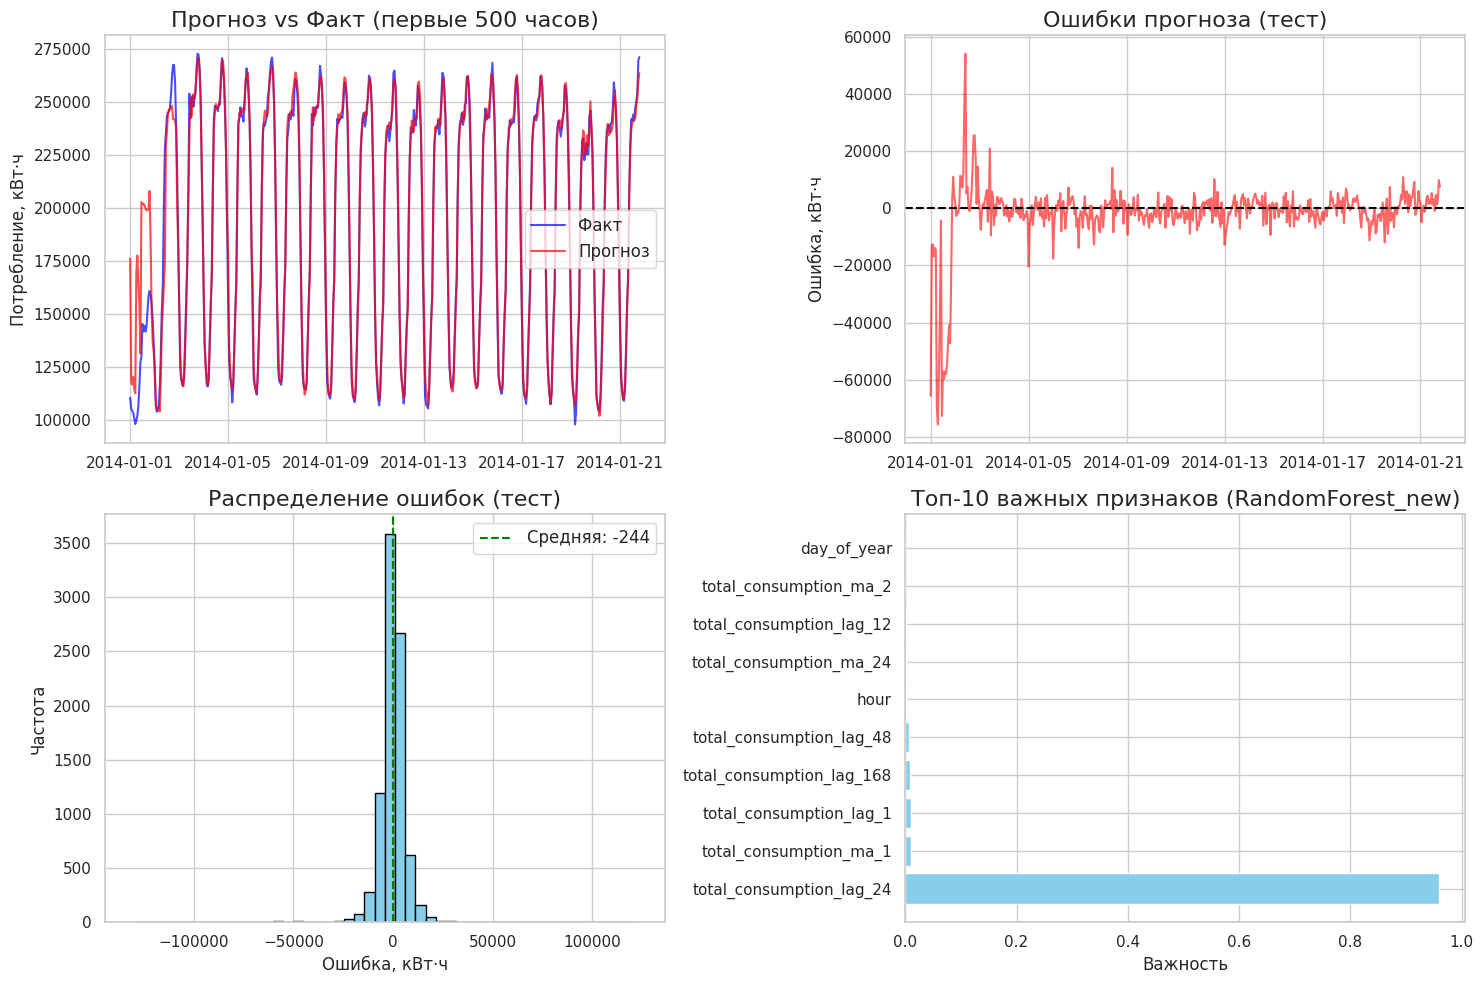

<Figure size 1200x600 with 0 Axes>

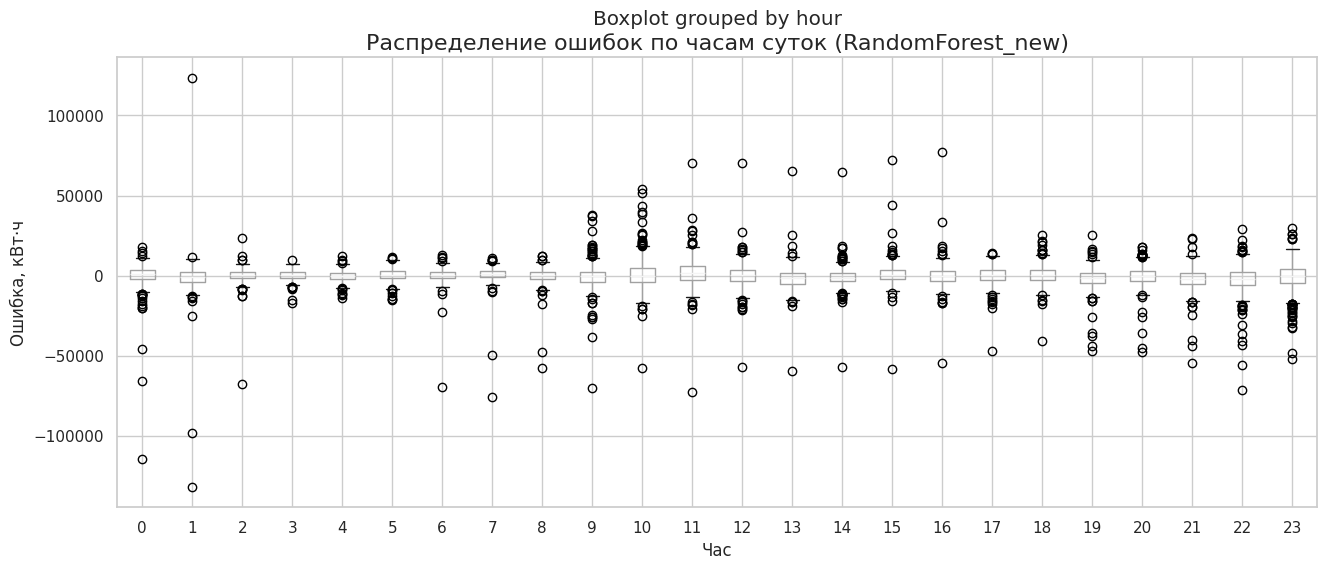


- Статистика ошибок по часам:
      count      mean       std         min       25%       50%      75%  \
hour                                                                       
0    366.00      5.00  8,963.75 -114,824.35 -2,144.68  1,141.77 3,437.09   
1    365.00 -1,158.29 11,695.45 -131,939.10 -3,743.30   -778.94 2,068.23   
2    365.00    168.59  4,918.70  -67,815.70 -1,452.89    385.21 2,325.21   
3    365.00    336.87  3,102.60  -16,902.33 -1,497.44    511.72 2,074.28   
4    365.00   -348.84  3,321.93  -13,846.30 -2,155.15   -147.08 1,645.96   
5    365.00    484.15  3,947.89  -15,342.00 -1,505.93    671.44 2,968.12   
6    365.00    202.94  5,068.76  -69,771.83 -1,688.52    295.69 2,455.03   
7    365.00    638.58  5,683.94  -75,700.35   -636.30    907.19 2,968.19   
8    365.00    -97.60  5,467.70  -58,015.24 -2,221.85    419.37 2,246.52   
9    365.00   -560.55  8,478.44  -70,430.13 -3,746.31   -549.06 2,503.71   
10   365.00  1,107.72 10,051.43  -57,736.44 -4,216.20   -

In [ ]:
# ----- ВИЗУАЛИЗАЦИЯ ДЛЯ RANDOMFOREST  -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ RANDOMFOREST NEW" + color.END)
print("="*80)

# берем лучшую модель
best_model = result_rf_new['model']

# предсказания
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# ----- 1. ГРАФИКИ -----
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1.1 Прогноз vs факт
test_subset = 500
axes[0, 0].plot(y_test.index[:test_subset], y_test.values[:test_subset],
                label='Факт', color='blue', alpha=0.7)
axes[0, 0].plot(y_test.index[:test_subset], y_pred_test[:test_subset],
                label='Прогноз', color='red', alpha=0.7)
axes[0, 0].set_title('Прогноз vs Факт (первые 500 часов)')
axes[0, 0].set_ylabel('Потребление, кВт·ч')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 1.2 Ошибки прогноза
errors_test = y_test.values - y_pred_test
axes[0, 1].plot(y_test.index[:test_subset], errors_test[:test_subset],
                color='red', alpha=0.6)
axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].set_title('Ошибки прогноза (тест)')
axes[0, 1].set_ylabel('Ошибка, кВт·ч')
axes[0, 1].grid(True)

# 1.3 Распределение ошибок
axes[1, 0].hist(errors_test, bins=50, color='skyblue', edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--')
axes[1, 0].axvline(x=np.mean(errors_test), color='green', linestyle='--',
                   label=f'Средняя: {np.mean(errors_test):.0f}')
axes[1, 0].set_title('Распределение ошибок (тест)')
axes[1, 0].set_xlabel('Ошибка, кВт·ч')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 1.4 Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(10)
axes[1, 1].barh(top_features['feature'], top_features['importance'], color='skyblue')
axes[1, 1].set_title('Топ-10 важных признаков (RandomForest_new)')
axes[1, 1].set_xlabel('Важность')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# ----- 2. ОШИБКИ ПО ЧАСАМ -----

errors_by_hour = pd.DataFrame({
    'hour': y_test.index.hour,
    'error': errors_test
})

plt.figure(figsize=(12, 6))
errors_by_hour.boxplot(by='hour', figsize=(15, 6))
plt.title('Распределение ошибок по часам суток (RandomForest_new)')
plt.xlabel('Час')
plt.ylabel('Ошибка, кВт·ч')
plt.grid(True)
plt.show()

print("\n- Статистика ошибок по часам:")
print(errors_by_hour.groupby('hour')['error'].describe())

# ----- 3. ТОП-20 ВАЖНЫХ ПРИЗНАКОВ -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ТОП-20 ВАЖНЫХ ПРИЗНАКОВ (RandomForest_new)" + color.END)
print("="*80)
print(feature_importance.head(20).to_string(index=False))

print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"ГОТОВО!" + color.END)
print("="*80)

Самым важным признаком остался суточный лаг, сохраняются проблемы с первыми часами года и переходом на летнее/зимнее время. Сама модель теперь чаще и сильнее склонна к занижению, чем к завышению.

Самый важный признак с той же "силой" по-прежнему суточный лаг, и лишь одно скользящее среднее (1) получило хоть какую-то, хоть и очень слабую, важность. То есть модель не смогла эфффективно использовать новые признаки.


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ XGBoost NEW


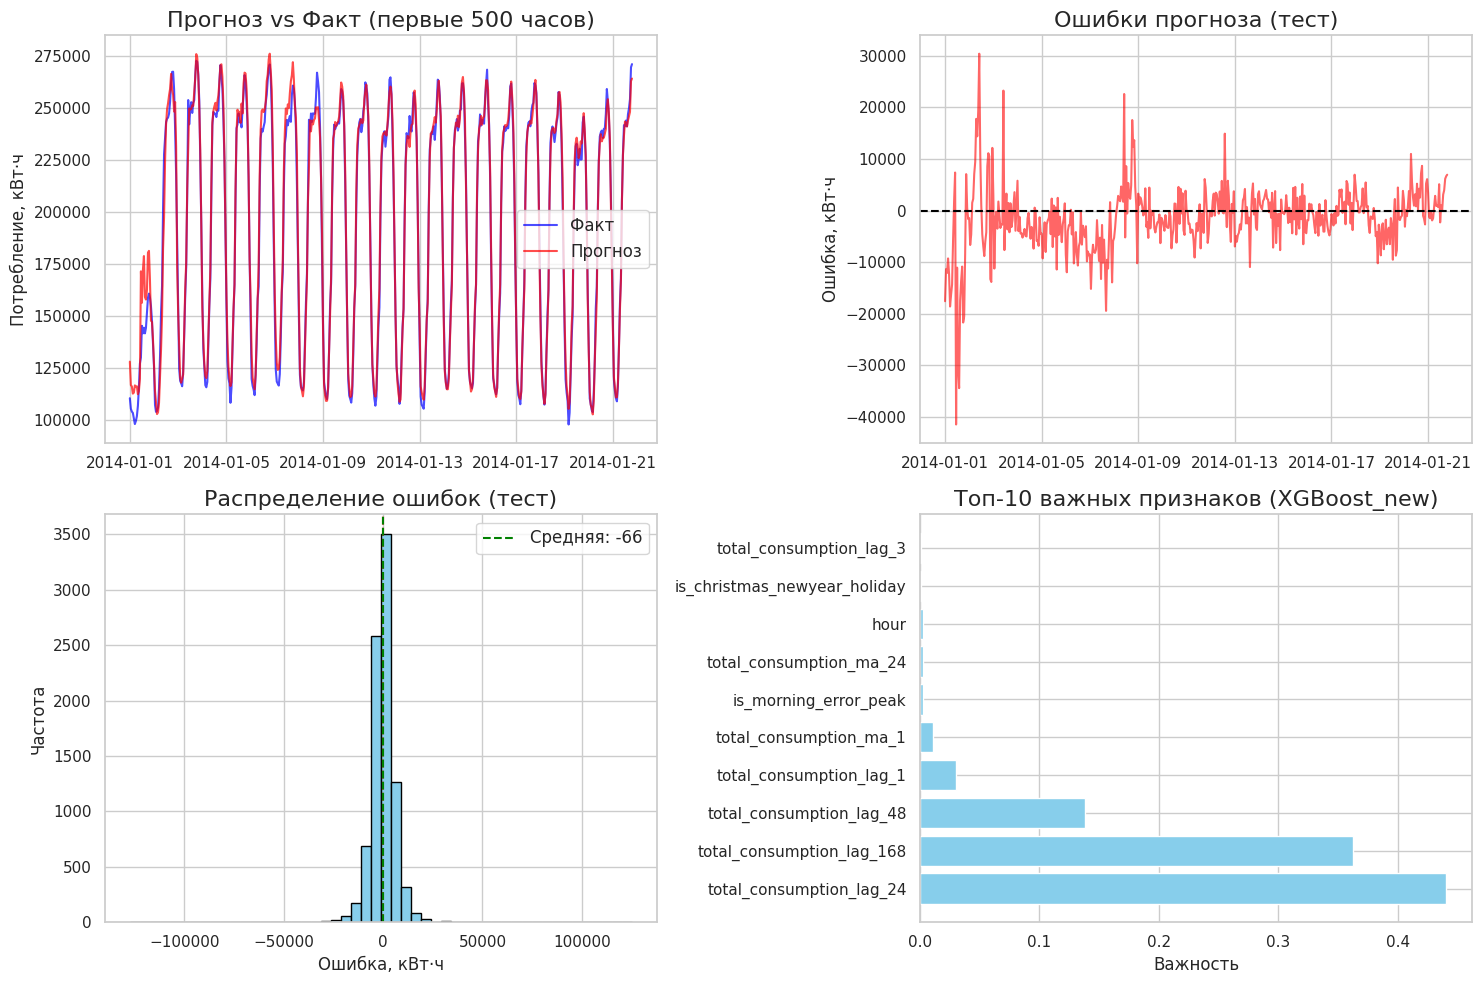

<Figure size 1200x600 with 0 Axes>

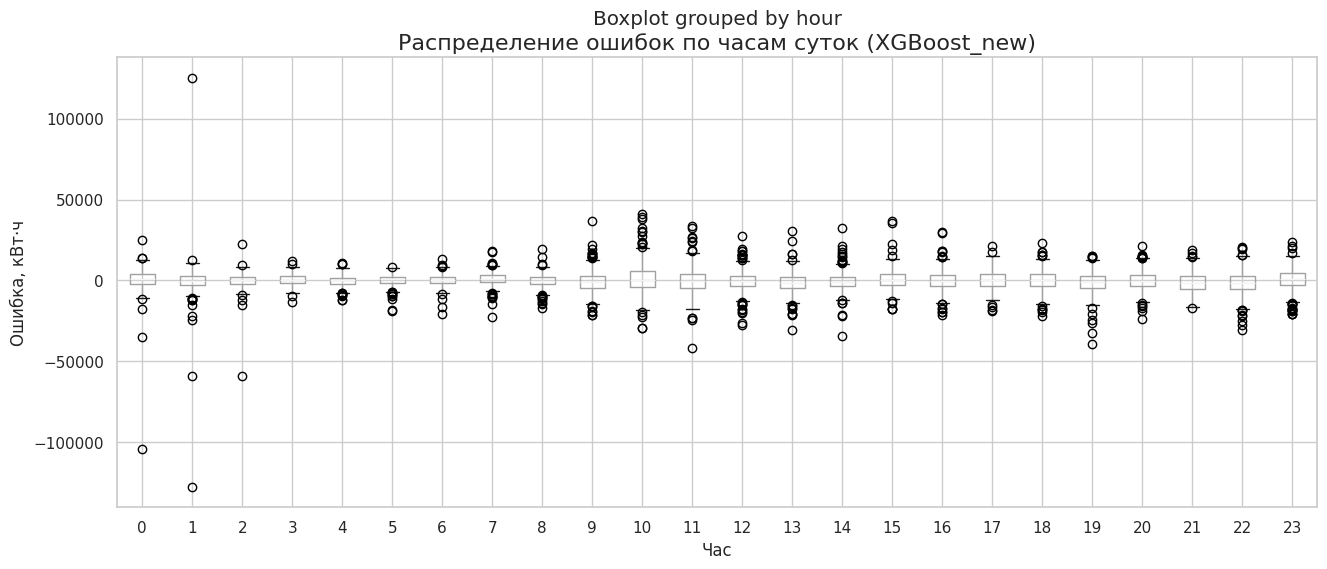


- Статистика ошибок по часам:
      count      mean       std         min       25%       50%      75%  \
hour                                                                       
0    366.00    762.61  7,524.17 -104,071.28 -2,061.38    995.82 4,016.35   
1    365.00   -257.87 10,807.19 -127,422.77 -2,643.24   -294.74 2,800.36   
2    365.00    106.62  4,733.03  -58,917.96 -1,976.32    226.23 2,379.84   
3    365.00    365.30  3,255.71  -13,070.11 -1,789.74    280.70 2,539.34   
4    365.00   -121.40  3,291.23  -12,325.80 -2,091.45     29.34 1,825.88   
5    365.00    416.35  3,548.35  -18,607.66 -1,556.21    626.38 2,276.06   
6    365.00    146.70  3,587.93  -20,951.44 -1,839.17    170.55 2,226.31   
7    365.00    898.61  4,006.96  -22,766.82   -943.57  1,050.27 3,173.62   
8    365.00   -298.14  4,249.07  -17,188.76 -2,451.03   -100.77 1,971.64   
9    365.00   -816.24  6,812.36  -21,333.76 -4,508.88   -790.83 2,538.56   
10   365.00  1,446.67  9,228.10  -29,605.98 -4,182.38    

In [ ]:
# ----- ВИЗУАЛИЗАЦИЯ ДЛЯ XGBoost -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ XGBoost NEW" + color.END)
print("="*80)

# берем лучшую модель
best_model = result_xgb_new['model']

# предсказания
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# ----- 1. ГРАФИКИ -----
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1.1 Прогноз vs факт
test_subset = 500
axes[0, 0].plot(y_test.index[:test_subset], y_test.values[:test_subset],
                label='Факт', color='blue', alpha=0.7)
axes[0, 0].plot(y_test.index[:test_subset], y_pred_test[:test_subset],
                label='Прогноз', color='red', alpha=0.7)
axes[0, 0].set_title('Прогноз vs Факт (первые 500 часов)')
axes[0, 0].set_ylabel('Потребление, кВт·ч')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 1.2 Ошибки прогноза
errors_test = y_test.values - y_pred_test
axes[0, 1].plot(y_test.index[:test_subset], errors_test[:test_subset],
                color='red', alpha=0.6)
axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].set_title('Ошибки прогноза (тест)')
axes[0, 1].set_ylabel('Ошибка, кВт·ч')
axes[0, 1].grid(True)

# 1.3 Распределение ошибок
axes[1, 0].hist(errors_test, bins=50, color='skyblue', edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--')
axes[1, 0].axvline(x=np.mean(errors_test), color='green', linestyle='--',
                   label=f'Средняя: {np.mean(errors_test):.0f}')
axes[1, 0].set_title('Распределение ошибок (тест)')
axes[1, 0].set_xlabel('Ошибка, кВт·ч')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 1.4 Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(10)
axes[1, 1].barh(top_features['feature'], top_features['importance'], color='skyblue')
axes[1, 1].set_title('Топ-10 важных признаков (XGBoost_new)')
axes[1, 1].set_xlabel('Важность')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# ----- 2. ОШИБКИ ПО ЧАСАМ -----

errors_by_hour = pd.DataFrame({
    'hour': y_test.index.hour,
    'error': errors_test
})

plt.figure(figsize=(12, 6))
errors_by_hour.boxplot(by='hour', figsize=(15, 6))
plt.title('Распределение ошибок по часам суток (XGBoost_new)')
plt.xlabel('Час')
plt.ylabel('Ошибка, кВт·ч')
plt.grid(True)
plt.show()

print("\n- Статистика ошибок по часам:")
print(errors_by_hour.groupby('hour')['error'].describe())

# ----- 3. ТОП-20 ВАЖНЫХ ПРИЗНАКОВ -----

print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ТОП-20 ВАЖНЫХ ПРИЗНАКОВ (XGBoost_new)" + color.END)
print("="*80)
print(feature_importance.head(20).to_string(index=False))

print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"ГОТОВО!" + color.END)
print("="*80)

Модель также сохраняет проблемы с предсказанием в первые часы года и переходе на летнее/зимнее время. Также имеются сохранилась склонность как к завышению. так и к занижению, однако абсолютные величины в целом стали меньше.

Среди важности признаков вместо лагов первые места заняли аналогичные им скользящие средние - то есть модель эффективно распорядилась новыми признаками.

### **Выводы**

Мною были заново подготовлены данные для обучения моделей, которые включали в качестве признаков:
- лаги для общего потребления;
- скользящие средние;
- временные признаки (например, день недели), с добавленными в текущее испытание утренними и вечерними пиками.

Затем обучено те же три модели и сравнены и проанализированны результаты.

В целом, изменение набора признаков пошло моделям на пользу, однако Случайный лес (прошлый победител) не смог эффективно распорядиться новыми признаками, в то время как обновленный XGBoost прняв скользящие средние за самые важные признаки улучшил свои абсолютные метрики и вырвался вперед.

И хотя XGBoost_new по прежнему сохранил проблемы своего предшественника (проблемы с предсказанием первых часов года и перехода на летнее/зимнее время, сколонности к завышению и занижению), его абсолютные значения ошибок в целом уменьшились (увеличение же относительной ошибки является скорее следствием характера данных, чем проблемами в самой модели).

В результате ввиду наличия лучших абсолютных метрик на кросс-валидации и тесте XGBoost_new был признан лучшей моделью.

## **Дополнительная работа**

В рамках экспериментов я попробую испытать одну специализированную модель и улучшить лучшую из ранее обученных моделей.

### **Дополнительные улучшения модели-победителя**

Выведу еще раз важность признаков XGBoost_new перед отбором.

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost_new)" + color.END)
print("="*80)

# берем лучшую модель
best_model = result_xgb_new['model']

# создаем датафрейм с важностью
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# показываем все признаки с их важностью
print(feature_importance.to_string(index=False))


ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost_new)
                     feature  importance
    total_consumption_lag_24        0.44
   total_consumption_lag_168        0.36
    total_consumption_lag_48        0.14
     total_consumption_lag_1        0.03
      total_consumption_ma_1        0.01
       is_morning_error_peak        0.00
     total_consumption_ma_24        0.00
                        hour        0.00
is_christmas_newyear_holiday        0.00
     total_consumption_lag_3        0.00
                 day_of_year        0.00
                  is_weekend        0.00
                 day_of_week        0.00
    total_consumption_lag_12        0.00
     total_consumption_ma_48        0.00
      total_consumption_ma_2        0.00
     total_consumption_ma_12        0.00
    total_consumption_ma_168        0.00
     total_consumption_lag_6        0.00
             is_evening_peak        0.00
     total_consumption_lag_2        0.00
                       month        0.00
      total_consumption

Теперь выведу признаки с низкой важностью, которые, потенциально, можно удалить.

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ПРИЗНАКИ С ВАЖНОСТЬЮ < 1%" + color.END)
print("="*80)

# отбираем признаки с важностью < 0.01 (1%)
low_importance = feature_importance[feature_importance['importance'] < 0.01]
print(color.BLUE + color.BOLD + f"Количество признаков с важностью < 1%: {len(low_importance)}"+ color.END)
print(low_importance.to_string(index=False))


ПРИЗНАКИ С ВАЖНОСТЬЮ < 1%
Количество признаков с важностью < 1%: 19
                     feature  importance
       is_morning_error_peak        0.00
     total_consumption_ma_24        0.00
                        hour        0.00
is_christmas_newyear_holiday        0.00
     total_consumption_lag_3        0.00
                 day_of_year        0.00
                  is_weekend        0.00
                 day_of_week        0.00
    total_consumption_lag_12        0.00
     total_consumption_ma_48        0.00
      total_consumption_ma_2        0.00
     total_consumption_ma_12        0.00
    total_consumption_ma_168        0.00
     total_consumption_lag_6        0.00
             is_evening_peak        0.00
     total_consumption_lag_2        0.00
                       month        0.00
      total_consumption_ma_3        0.00
      total_consumption_ma_6        0.00


Таких признаков 19, то есть при их удалении общее количество признаков, используемых для работы модели, значительно уменьшиться (с 24 до 5), что должно облегчить подготовку данных, снизить необходимые вычислительные мощности и ускорить процесс предсказния.

Создам новый датафрейм с ними.

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"СОЗДАНИЕ ДАТАФРЕЙМА С ТОП-ПРИЗНАКАМИ" + color.END)
print("="*80)

# выбираем только топ-5 признаков
top_5_features_list = feature_importance.head(5)['feature'].tolist()

# создаем новый X_train и X_test только с этими признаками
X_train_top5 = X_train[top_5_features_list]
X_test_top5 = X_test[top_5_features_list]

print(f"Количество признаков: {len(top_5_features_list)}")
print(f"Размер X_train_top6: {X_train_top5.shape}")
print(f"Размер X_test_top6: {X_test_top5.shape}")
print(f"\nТоп-5 признаков:")
print(top_5_features_list)


СОЗДАНИЕ ДАТАФРЕЙМА С ТОП-ПРИЗНАКАМИ
Количество признаков: 5
Размер X_train_top6: (26136, 5)
Размер X_test_top6: (8761, 5)

Топ-5 признаков:
['total_consumption_lag_24', 'total_consumption_lag_168', 'total_consumption_lag_48', 'total_consumption_lag_1', 'total_consumption_ma_1']


Обучу модель на этих 5 самых важных по мнению лучшей модели признаках.

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ОБУЧЕНИЕ XGBOOST НА ТОП-5 ПРИЗНАКАХ" + color.END)
print("="*80)

# используем ту же функцию, но с новыми данными
%time result_xgb_top5 = XGBoost_Regressor(X_train_top5, y_train)

# делаем предсказания
y_pred_top5 = result_xgb_top5['model'].predict(X_test_top5)

# считаем метрики
mae_top5 = mean_absolute_error(y_test, y_pred_top5)
rmse_top5 = np.sqrt(mean_squared_error(y_test, y_pred_top5))
r2_top5 = r2_score(y_test, y_pred_top5)
mape_top5 = np.mean(np.abs((y_test - y_pred_top5) / y_test)) * 100

print(f"\n📊 Результаты на топ-5 признаках:")
print(f"   MAE:  {mae_top5:.2f} кВт·ч")
print(f"   RMSE: {rmse_top5:.2f} кВт·ч")
print(f"   R²:   {r2_top5:.4f}")
print(f"   MAPE: {mape_top5:.2f}%")


ОБУЧЕНИЕ XGBOOST НА ТОП-5 ПРИЗНАКАХ
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Лучшее MAE при обучении: 14195.8300
Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}

CPU times: user 2.89 s, sys: 419 ms, total: 3.31 s
Wall time: 2min 37s

📊 Результаты на топ-5 признаках:
   MAE:  5854.93 кВт·ч
   RMSE: 8835.29 кВт·ч
   R²:   0.9878
   MAPE: 6.00%


In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"СРАВНЕНИЕ: ПОЛНАЯ МОДЕЛЬ vs ТОП-5" + color.END)
print("="*80)

# метрики полной модели
full_mae = models_dict['XGBoost_new']['MAE_test']
full_rmse = models_dict['XGBoost_new']['RMSE_test']
full_r2 = models_dict['XGBoost_new']['R2_test']
full_mape = models_dict['XGBoost_new']['MAPE_test']

print(color.BLUE + color.BOLD + f"\n Полная модель (все признаки):"+ color.END)
print(f"   MAE:  {full_mae:.2f} кВт·ч")
print(f"   RMSE: {full_rmse:.2f} кВт·ч")
print(f"   R²:   {full_r2:.4f}")
print(f"   MAPE: {full_mape:.2f}%")

print(color.BLUE + color.BOLD + f"\n Топ-5 признаков:"+ color.END)
print(f"   MAE:  {mae_top5:.2f} кВт·ч")
print(f"   RMSE: {rmse_top5:.2f} кВт·ч")
print(f"   R²:   {r2_top5:.4f}")
print(f"   MAPE: {mape_top5:.2f}%")

# вычисляем разницу
diff_mae = full_mae - mae_top5
diff_percent = (diff_mae / full_mae) * 100

if diff_mae > 0:
    print(color.GREEN + color.BOLD + f"\n V Топ-5 признаков лучше на {diff_mae:.2f} кВт·ч ({diff_percent:.2f}%)"+ color.END)
else:
    print(color.NEWYELLOW + color.BOLD + f"\n ! Полная модель лучше на {-diff_mae:.2f} кВт·ч ({-diff_percent:.2f}%)"+ color.END)


СРАВНЕНИЕ: ПОЛНАЯ МОДЕЛЬ vs ТОП-5

 Полная модель (все признаки):
   MAE:  4250.01 кВт·ч
   RMSE: 6349.84 кВт·ч
   R²:   0.9937
   MAPE: 5.22%

 Топ-5 признаков:
   MAE:  5854.93 кВт·ч
   RMSE: 8835.29 кВт·ч
   R²:   0.9878
   MAPE: 6.00%

 ! Полная модель лучше на 1604.92 кВт·ч (37.76%)


То есть несмотря на то, что удаленные признаки не показывали какой-либо заметной важности в модели, их удаление привело к ухудшению качества этой самой модели.

### **Эксперимент с Prophet**

До этого я использовала неспециализированные модели и добилась неплохих метрик. Теперь в качестве эксперимента я попробую применить специально разработанную для целей предсказания временных рядов модель.

Такой моделью станет Prophet, потому что он из коробки умеет работать с мультипликативной сезонностью, а при анализе ранее уже выяснилось, что для имеющихся данных это подходит лучше, чем аддитивность.

Создание признаков уже встроено в саму модель, поэтому подготовка данных будет небольшой.

In [ ]:
# готовим данные для Prophet
df_prophet = df_two_features[['total_consumption']].reset_index()
df_prophet.columns = ['ds', 'y']  # переименовываем

# оставляем только 2011-2013 для обучения (как у других моделей)
train_prophet = df_prophet[df_prophet['ds'] < '2014-01-01']
test_prophet = df_prophet[df_prophet['ds'] >= '2014-01-01']

print(f"- Обучающая выборка: {train_prophet.shape[0]} строк ({train_prophet['ds'].min()} — {train_prophet['ds'].max()})")
print(f"- Тестовая выборка: {test_prophet.shape[0]} строк ({test_prophet['ds'].min()} — {test_prophet['ds'].max()})")

- Обучающая выборка: 26304 строк (2011-01-01 00:00:00 — 2013-12-31 23:00:00)
- Тестовая выборка: 8761 строк (2014-01-01 00:00:00 — 2015-01-01 00:00:00)


Количества строк и периоды аналогичны ранее использовавшимся.

Упакую модель в функцию по аналогии с используемыми ранее для деревьев.

In [ ]:
# функция с моделью Prophet
# с мультипликативной сезонностью
# с кросс-валидацией
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Prophet_Regressor(X_train, y_train):
    """
    Обучает Prophet с мультипликативной сезонностью.

    Параметры:
    ----------
    X_train, y_train : данные для обучения
    X_test, y_test : данные для теста (для оценки)

    Возвращает:
    -----------
    dict : {'model', 'best_mae', 'best_params'}
    """

    # ----- 1. ПОДГОТОВКА ДАННЫХ ДЛЯ PROPHET -----
    # Prophet требует строгого формата: колонки ds (дата) и y (значение)
    train_data = pd.DataFrame({
        'ds': X_train.index,
        'y': y_train.values
    })

    test_data = pd.DataFrame({
        'ds': X_test.index,
        'y': y_test.values
    })

    # ----- 2. ОБУЧЕНИЕ МОДЕЛИ -----
    # seasonality_mode='multiplicative' — мультипликативная сезонность
    # (подходит для растущего тренда, сезонные колебания усиливаются со временем)
    # yearly_seasonality=True — годовая сезонность (есть в данных)
    # weekly_seasonality=True — недельная сезонность (есть в данных)
    # daily_seasonality=True — суточная сезонность (есть в данных)
    # changepoint_prior_scale=0.05 — гибкость тренда (стандартное значение)
    # seasonality_prior_scale=10.0 — гибкость сезонности (стандартное значение)
    # interval_width=0.95 — доверительный интервал 95%
    model = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        interval_width=0.95
    )

    # обучаем модель
    model.fit(train_data)

    # ----- 3. КРОСС-ВАЛИДАЦИЯ (WALK-FORWARD) -----
    # для временных рядов используем скользящую кросс-валидацию
    # initial='730 days' — первый обучающий период = 2 года
    # period='90 days' — сдвиг окна на 3 месяца
    # horizon='168 hours' — прогноз на 7 дней (168 часов)
    # parallel='processes' — параллельные вычисления для ускорения
    df_cv = cross_validation(
        model,
        initial='730 days',
        period='90 days',
        horizon='168 hours',
        parallel='processes'
    )

    # вычисляем метрики по всем сплитам кросс-валидации
    df_metrics = performance_metrics(df_cv)
    best_mae = df_metrics['mae'].mean()  # средний MAE по всем сплитам

    # ----- 4. ПАРАМЕТРЫ -----
    # фиксируем параметры модели (для сравнения в словаре)
    best_params = {
        'seasonality_mode': 'multiplicative',
        'yearly_seasonality': True,
        'weekly_seasonality': True,
        'daily_seasonality': True,
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 10.0
    }

    # ----- 5. ВЫВОД -----
    print(color.BLUE + color.BOLD + f"Лучшее MAE (CV): " \
          + color.END + f"{best_mae:.4f}")
    print(color.BLUE + color.BOLD + f"Параметры: " \
          + color.END + f"{best_params}\n")

    # ----- 6. ВОЗВРАТ (как в других моделях) -----
    # возвращаем словарь для единого сравнения с другими моделями
    return {
        'model': model,           # обученная модель Prophet
        'best_mae': best_mae,     # MAE с кросс-валидации
        'best_params': best_params # параметры модели
    }

In [ ]:
# тренируем модель
# засекая время обучения
%time result_prophet = Prophet_Regressor(X_train, y_train)

INFO:prophet:Making 4 forecasts with cutoffs between 2013-03-29 23:00:00 and 2013-12-24 23:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7c785f12b200>


Лучшее MAE (CV): 34766.9778
Параметры: {'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': True, 'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0}

CPU times: user 3.38 s, sys: 102 ms, total: 3.48 s
Wall time: 4min 1s


In [ ]:
# так как prophet работает несколько иначе, то для заполнения словаря нужна небольшая подготовка
# ----- ПРОГНОЗ ДЛЯ PROPHET -----

# создаем future датафрейм (как подготовка X_test для других моделей)
future = result_prophet['model'].make_future_dataframe(
    periods=len(y_test),
    freq='h',
    include_history=False
)

# получаем предсказания (как .predict(X_test) у других моделей)
y_pred_test = result_prophet['model'].predict(future)['yhat'].values

# ----- ДОБАВЛЯЕМ В СЛОВАРЬ (ТЕПЕРЬ КАК У ВСЕХ) -----

models_dict['Prophet'] = {
    # Для настройки параметров (внутренний критерий)
    'MAE_CV': round(result_prophet['best_mae'], 4),

    # ГЛАВНЫЕ МЕТРИКИ ДЛЯ СРАВНЕНИЯ (внешний критерий)
    'MAE_test': round(mean_absolute_error(y_test, y_pred_test), 4),
    'RMSE_test': round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4),
    'R2_test': round(r2_score(y_test, y_pred_test), 4),
    'MAPE_test': round(np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100, 2),

    'params': result_prophet['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"
RandomForest,"14,066.34","4,794.42","8,030.33",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost,"14,526.42","6,670.57","9,369.05",0.99,3.61,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}"
DTR_new,"15,810.48","5,653.74","8,988.66",0.99,6.01,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 20}"
RandomForest_new,"14,224.98","4,333.50","7,387.16",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost_new,"14,306.69","4,250.01","6,349.84",0.99,5.22,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}"
Prophet,"34,766.98","112,708.42","137,868.99",-1.96,51.14,"{'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': True, 'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0}"


Не смотря на то, что Prophet специально разработан для предсказания временных рядов он справился хуже, чем примененные ранее деревья.

Возможные причины:
-  Модель не знает о почасовых пиках. Prophet видит только глобальный тренд и сезонность (годовую, недельную, суточную). И не видит резких скачков (утренние/вечерние пики), которые отлично ловят XGBoost и RandomForest через лаги (lag_24, lag_1).
- Несмотря на выброр мультипликативной модели, Prophet просто не имеет достаточно "гибкости", чтобы уловить сложные паттерны потребления.
- Отсутствие внешних признаков: Prophet использует только временные признаки (дата, час, день недели) в то время как у XGBoost были лаги, скользящие средние, пиковые часы, праздники — всё это дало модели огромное преимущество.

Метрика R² = -1.96 означает, что Prophet предсказывает хуже, чем просто среднее значение, то есть модель полностью провалилась.


### **Выводы**
Было произведено два эксперимента, оба из которых не привели к появлению хороших метрик:

- Попытка уменьшить количество признаков для обучения модели XGBoost_new убрав все, что имели менее 1% важности. Это уменьшило их количество с 24 до 5, однако привело к ухудшению как абсолютных, так и относительных метрик модели (главная метрика, MAE, на тесте выросла у эксперементальной модели на 37.76% относительно исходной для нее XGBoost_new).

- В рамках эксперимента со специализированной для временных рядов моделью на имеющихся данных модель Prophet не сумела уловить сложные паттерны поведения и показала худшие из возможных метрик (хуже, чем просто среднее значение).

## **Дополнительный анализ лучшей модели**

Выведу как же выглядело статистическое описание взятого для подготовки признаков для работы с моделями датасета, чтобы метрики модели были более наглядны.

In [ ]:
# числовое описание данных (с транспонированием)
df_two_features.describe().T

,count,mean,std,min,25%,50%,75%,max
total_consumption,35065.0,195551.365542,83895.020451,454.479877,131454.146829,168249.028704,248195.154033,448148.758471
active_clients,35065.0,295.938143,80.789981,118.000000,315.000000,331.000000,348.000000,369.000000


На фоне имеющихся данных лучшая из моделей (XGBoost_new) показала хорошую точность для подобного сложного и волятивного ряда.

Как можно было увидеть ранее, MAE на тесте признанной лучшей из моделей XGBoost_new составила 4 250 при среднем потреблениии 195 551. То есть модель ошибается в среднем на 2.17% от среднего потребления — это отличный результат для прогнозирования энергопотребления.

Разберу ошибки модели чуть подробнее.



In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"АНАЛИЗ ОШИБОК МОДЕЛИ ПО КВАРТИЛЯМ ПОТРЕБЛЕНИЯ" + color.END)
print("="*80)
print(color.BLUE + f"Модель: XGBoost_new" + color.END)
print(color.BLUE + f"Метрики: MAE, MAPE, MAE_%" + color.END)
print("="*80)

# 1. Разбиваем тестовые данные на квартили по фактическому потреблению
y_test_quantiles = pd.qcut(y_test, q=4, labels=['min', '25%', '50%', '75%'])

# 2. Считаем MAE в каждой группе
errors_by_quantile = pd.DataFrame({
    'fact': y_test,
    'pred': y_pred_test,
    'quantile': y_test_quantiles
})

# 3. Группируем и считаем метрики
def calc_metrics(group):
    mae = mean_absolute_error(group['fact'], group['pred'])
    mape = np.mean(np.abs((group['fact'] - group['pred']) / group['fact'])) * 100
    return pd.Series({
        'count': len(group),
        'mean_fact': group['fact'].mean(),
        'MAE': mae,
        'MAPE': mape,
        'MAE_percent': (mae / group['fact'].mean()) * 100
    })

result = errors_by_quantile.groupby('quantile', observed=False).apply(calc_metrics, include_groups=False)
print(result.round(2))

print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"V Анализ по квартилям завершён!" + color.END)
print("="*80)


АНАЛИЗ ОШИБОК МОДЕЛИ ПО КВАРТИЛЯМ ПОТРЕБЛЕНИЯ
Модель: XGBoost_new
Метрики: MAE, MAPE, MAE_%
            count  mean_fact      MAE  MAPE  MAE_percent
quantile                                                
min      2,191.00 129,054.85 3,294.07  5.36         2.55
25%      2,190.00 184,890.79 4,383.17  2.38         2.37
50%      2,190.00 249,788.57 9,713.79  3.86         3.89
75%      2,190.00 333,864.54 9,292.78  2.85         2.78

V Анализ по квартилям завершён!


Краткий анализ

| Квартиль | Главный вывод | Интерпретация для бизнеса |
| :--- | :--- | :--- |
| **min** (низкое потребление) | MAE = 3 294 кВт·ч — **самая низкая абсолютная ошибка**,<br> но MAPE = 5.36% — **самая высокая** (маленькие значения → большие проценты) | Отличная точность |
| **25%** | MAE = 4 383 кВт·ч,<br> MAPE = 2.38% — **лучший MAPE** | **Идеально** |
| **50%** | MAE = 9 714 кВт·ч — **самая высокая абсолютная ошибка** <br>(в этом диапазоне сложнее прогнозировать) | Хорошо, но можно улучшить |
| **75%** | MAE = 9 293 кВт·ч — почти как у 50% |Отличная точность |

То есть:
- Модель лучше всего работает на средних значениях (25% квартиль): MAPE = 2.38%
- На пиковых значениях ошибка выше (MAE = 9 714), но в процентах она всё равно низкая (3.89%).
- Ночью ошибка в абсолютных цифрах самая низкая (3 294), что важно для бизнеса, хотя MAPE выше из-за маленьких значений.
- Модель стабильна на всех уровнях потребления.

Взгляну ошибки дополнительно по периодам суток.

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"АНАЛИЗ ОШИБОК МОДЕЛИ ПО ЧАСАМ СУТОК" + color.END)
print("="*80)
print(color.BLUE + f"Модель: XGBoost_new" + color.END)
print(color.BLUE + f"Метрика: MAPE (средняя абсолютная процентная ошибка)" + color.END)
print("="*80)

# разбиваем по часам
errors_by_hour = pd.DataFrame({
    'hour': y_test.index.hour,
    'fact': y_test,
    'pred': y_pred_test,
    'error': y_test - y_pred_test
})

# правильный MAPE по часам
hourly_stats_correct = errors_by_hour.groupby('hour').agg({
    'fact': 'mean',
    'error': 'mean',
    'pred': 'mean'
}).round(2)

# считаем MAPE правильно (по каждому наблюдению в группе)
hourly_stats_correct['MAPE'] = errors_by_hour.groupby('hour').apply(
    lambda x: np.mean(np.abs((x['fact'] - x['pred']) / x['fact'])) * 100
).round(2)

print(color.BLUE + color.BOLD + f"\nНочь (0-5):" + color.END)
print(hourly_stats_correct.loc[0:5])

print(color.BLUE + color.BOLD + f"\nУтро (6-8):" + color.END)
print(hourly_stats_correct.loc[6:8])

print(color.BLUE + color.BOLD + f"\nУтренний пик (9-12):" + color.END)
print(hourly_stats_correct.loc[9:12])

print(color.BLUE + color.BOLD + f"\nДень (13-16):" + color.END)
print(hourly_stats_correct.loc[13:16])

print(color.BLUE + color.BOLD + f"\nВечерний пик (17-20):" + color.END)
print(hourly_stats_correct.loc[17:20])

print(color.BLUE + color.BOLD + f"\nПоздний вечер (21-23):" + color.END)
print(hourly_stats_correct.loc[21:23])

print("\n" + "="*80)
print(color.GREEN + color.BOLD + f"V Анализ завершён!" + color.END)
print("="*80)


АНАЛИЗ ОШИБОК МОДЕЛИ ПО ЧАСАМ СУТОК
Модель: XGBoost_new
Метрика: MAPE (средняя абсолютная процентная ошибка)

Ночь (0-5):
           fact    error       pred  MAPE
hour                                     
0    156,582.44 1,193.85 155,388.59  3.65
1    133,207.41 1,393.16 131,814.25 18.97
2    128,352.67   446.36 127,906.31  2.45
3    125,080.81   760.24 124,320.58  2.29
4    122,888.67   299.12 122,589.55  2.24
5    128,817.87   124.24 128,693.63  2.22

Утро (6-8):
           fact   error       pred  MAPE
hour                                    
6    143,164.97  300.93 142,864.03  2.03
7    157,740.36  782.98 156,957.38  2.04
8    169,794.52 -492.23 170,286.77  2.13

Утренний пик (9-12):
           fact    error       pred  MAPE
hour                                     
9    221,562.12 6,675.82 214,886.30  3.63
10   262,925.24 4,632.25 258,293.00  3.18
11   279,604.35 5,514.77 274,089.56  3.19
12   286,384.10 5,798.62 280,585.47  2.83

День (13-16):
           fact    error       pre

/tmp/ipykernel_6246/2165865739.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_stats_correct['MAPE'] = errors_by_hour.groupby('hour').apply(


In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"АНАЛИЗ АНОМАЛИЙ В ЧАСЕ 1:00" + color.END)
print("="*80)

# выделяем данные за час 1:00
hour_1_data = errors_by_hour[errors_by_hour['hour'] == 1]

# считаем MAPE для часа 1:00 вручную
mape_1 = np.mean(np.abs((hour_1_data['fact'] - hour_1_data['pred']) / hour_1_data['fact'])) * 100
print(f"MAPE для часа 1:00: {mape_1:.2f}%")

# смотрим распределение ошибок в час 1:00
print(f"\nСтатистика ошибок в час 1:00:")
print(hour_1_data['error'].describe())

# смотрим на выбросы
print(f"\nТоп-5 самых больших ошибок в час 1:00:")
print(hour_1_data.nlargest(5, 'error')[['fact', 'pred', 'error']])


АНАЛИЗ АНОМАЛИЙ В ЧАСЕ 1:00
MAPE для часа 1:00: 18.97%

Статистика ошибок в час 1:00:
count       365.00
mean      1,393.16
std       8,954.21
min     -60,225.53
25%      -1,425.71
50%       1,406.22
75%       4,129.31
max     126,138.65
Name: error, dtype: float64

Топ-5 самых больших ошибок в час 1:00:
                          fact       pred      error
timestamp                                           
2014-10-26 01:00:00 267,445.09 141,306.44 126,138.65
2014-11-11 01:00:00 137,246.62 123,977.30  13,269.31
2014-10-31 01:00:00 142,368.62 129,208.51  13,160.11
2014-08-02 01:00:00 163,388.19 150,386.19  13,002.00
2014-04-05 01:00:00 137,517.47 125,348.47  12,169.00


In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"ТОП-5 АНОМАЛЬНЫХ ДАТ В ЧАСЕ 1:00" + color.END)
print("="*80)

# смотрим, что происходит в час 1:00
hour_1 = errors_by_hour[errors_by_hour['hour'] == 1]

# группируем по датам, чтобы увидеть аномалии
hour_1_by_date = hour_1.groupby(hour_1['fact'].index.date).agg({
    'fact': 'mean',
    'pred': 'mean',
    'error': 'mean'
}).round(2)

# считаем MAPE по датам
hour_1_by_date['MAPE'] = hour_1.groupby(hour_1['fact'].index.date).apply(
    lambda x: np.mean(np.abs((x['fact'] - x['pred']) / x['fact'])) * 100
).round(2)

# показываем топ-5 дат с самой высокой ошибкой
print(hour_1_by_date.nlargest(5, 'MAPE'))


ТОП-5 АНОМАЛЬНЫХ ДАТ В ЧАСЕ 1:00
                 fact       pred      error     MAPE
2014-03-30     454.48  26,802.20 -26,347.72 5,797.34
2014-10-27 125,696.30 185,921.81 -60,225.53    47.91
2014-10-26 267,445.09 141,306.44 126,138.65    47.16
2014-11-02 140,435.23 175,581.81 -35,146.58    25.03
2014-12-25  92,312.12 115,126.99 -22,814.87    24.71


Можно наблюдать что:
- Положительные стороны:
  - Модель стабильна в большинстве часов (MAPE ~2–3%).
  - Утренние часы (6–12) и день (13–16) — предсказания очень точные.

- Проблемные моменты:
  - Час 1:00 — MAPE = 18.97% (аномалия!). Ей способствуют в том числе переходы на летнее и зимнее время.
  - Вечерний пик (20:00) — MAPE = 4.31%, ошибка в 11 343 кВт·ч — самая высокая абсолютная ошибка.
  - Поздний вечер (21:00) — MAPE = 3.73%, ошибка в 8 971 кВт·ч — вторая по величине.

Среди проблемных для 1:00 дат можно наблюдать даты перевода часов, а также католическое Рождество (что могло приводить к повышенному потреблению электричества в реальности, и повышеннным ошибкам в предсказаниях моделей) и некоторые другие праздники (и их кануны).

Однако в целом модель готова к использованию с учетом некоторых особенностей:
 - Прогнозу модели можно доверять в обычный день (ошибка минимальна);
 - Модель склонна ошибаться:
    - в дни перехода на летнее/зинее время (не учитывает "пропадание" и "удвоение часа") - ошибки увеличиваются для 23-го и 25-го часов (аномалия данных);
    - праздничные дни (повышается потребление электричества, ошибка выше обычной).

## **Итоговые выводы**

На анализ был получен датасет с потреблением электроэнергией 370 клиентами за период с с 2011-01-01 00:00:00 по 2015-01-01 00:00:00 с шагом в 15 минут. Краткий анализ подтвердил соответствие данных предоставляемым для них описанию, а также выявил наличие нескольких групп клиентов с потенциально разным потребительским поведением (вероятно - домохозяйства и предприятия).

От задачи кластеризации клиентов я отказалась, сосредоточившись на предсказании потребления без разбиения клиентов на группы.

Для обучения я выбрала модели, основанные на деревьях: Одиночное дерево решений (как базовую), а также по одному бэггингу (Случайный лес) и бустингу (XGBoost) как потенциально лучше работающих в равнении с линейными и не требующих дополнительной подготовки.

В качестве метрики я выбрала MAE как наиболее подходящую с учетом бизнес-задачи и возможных аномалий в данных.

Был подготовленн агрегированный датасет: ресемплированный по часу (так как для предсказания данный отрезок более удобен для бизнеса и понимания), переведенный из Кв в Кв*ч (чтобы точнее отражать предсказываемый признак - потребление в час), и обретший новые признаки (общее количество активных клиентов и их суммарное потребление).

На основе агрегированного датасета были подготовлены несколько датафреймов. Первый содержал лаги по обоим агрегированным признакам, а также временные признаки (например, день недели). Второй же (на основании результатов обучения первых моделей) уже исключил лаги для клиентов, но добавил скользящие для потребления, а также утренний и вечерний пики. Каждый из подготовленных таким образом датафреймов разбивался на тестовую и тренировочную выборку (2014 год и моложе - тест, остальное - обучение) и попадал на обучение ранее перечисленным моделям.

В результате на втором датафрейме была получена признанная лучшей из всех обученных в рамках проекта моделей XGBoost_new, чьи метрика MAE на тесте равна 4250.01, то есть ошибка составляет всего 2.17% от среднего потребления (которое равно 195551.365542).

Также был проведен эксперимент с обучением специализированной для временных рядов модели Prophet, однако метрики ее были очень плохи.


In [ ]:
# вывожу словарь для наглядности
pd.DataFrame.from_dict(models_dict, orient = 'index')

,MAE_CV,MAE_test,RMSE_test,R2_test,MAPE_test,params
DTR,"16,304.50","5,817.44","9,087.88",0.99,2.92,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 5}"
RandomForest,"14,066.34","4,794.42","8,030.33",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost,"14,526.42","6,670.57","9,369.05",0.99,3.61,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}"
DTR_new,"15,810.48","5,653.74","8,988.66",0.99,6.01,"{'max_depth': 10, 'max_features': None, 'min_samples_split': 20}"
RandomForest_new,"14,224.98","4,333.50","7,387.16",0.99,5.43,"{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 200}"
XGBoost_new,"14,306.69","4,250.01","6,349.84",0.99,5.22,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}"
Prophet,"34,766.98","112,708.42","137,868.99",-1.96,51.14,"{'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': True, 'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0}"


Признанная лучшей модель XGBoost_new считает важными признаками скользящие средние (остальные признаки вносят лишь небольшой вклад, однако их удаление привело к ухудшению качества модели).

In [ ]:
print("\n" + "="*80)
print(color.BLUE + color.BOLD + f"СРАВНЕНИЕ: ПОЛНАЯ МОДЕЛЬ vs ТОП-5" + color.END)
print("="*80)

# метрики полной модели
print(color.BLUE + color.BOLD + f"\n Полная модель (все признаки):"+ color.END)
print(f"   MAE:  {full_mae:.2f} кВт·ч")
print(f"   RMSE: {full_rmse:.2f} кВт·ч")
print(f"   R²:   {full_r2:.4f}")
print(f"   MAPE: {full_mape:.2f}%")

print(color.BLUE + color.BOLD + f"\n Топ-5 признаков:"+ color.END)
print(f"   MAE:  {mae_top5:.2f} кВт·ч")
print(f"   RMSE: {rmse_top5:.2f} кВт·ч")
print(f"   R²:   {r2_top5:.4f}")
print(f"   MAPE: {mape_top5:.2f}%")

# вычисляем разницу (была вычеслена ранее в соответствующем раздеде)

if diff_mae > 0:
    print(color.GREEN + color.BOLD + f"\n V Топ-5 признаков лучше на {diff_mae:.2f} кВт·ч ({diff_percent:.2f}%)"+ color.END)
else:
    print(color.NEWYELLOW + color.BOLD + f"\n ! Полная модель лучше на {-diff_mae:.2f} кВт·ч ({-diff_percent:.2f}%)"+ color.END)


СРАВНЕНИЕ: ПОЛНАЯ МОДЕЛЬ vs ТОП-5

 Полная модель (все признаки):
   MAE:  4250.01 кВт·ч
   RMSE: 6349.84 кВт·ч
   R²:   0.9937
   MAPE: 5.22%

 Топ-5 признаков:
   MAE:  5854.93 кВт·ч
   RMSE: 8835.29 кВт·ч
   R²:   0.9878
   MAPE: 6.00%

 ! Полная модель лучше на 1604.92 кВт·ч (37.76%)


Модель хорошо уловила тенденции данных и, хоть и имеет потенциал роста, уже готова к использованию с учетом некоторых особенностей:
 - Прогнозу модели можно доверять в обычный день (ошибка минимальна);
 - Модель склонна ошибаться:
    - в дни перехода на летнее/зинее время (не учитывает "пропадание" и "удвоение часа") - ошибки увеличиваются для 23-го и 25-го часов (аномалия данных);
    - праздничные дни (повышается потребление электричества, ошибка выше обычной).

## **Служебный код**

В данном разделе содержится код, способствующий воспроизводимости и подготавливающий проект к выкладке.

Для начала зафиксирую версии использованых библиотек, сохранив в файл requirements, который позже приложу к проекту.

In [ ]:
# создаём requirements.txt автоматически
!pip freeze > requirements.txt

print(color.GREEN + color.BOLD + f"V Файл requirements.txt создан!"+ color.END)

V Файл requirements.txt создан!


Так как ГитХаб бывает капризен, почищу ноутбук от различных метаданных для того, чтобы не было проблем с отображением проекта в репозитории.

In [ ]:
# Создаем чистую версию ноутбука
import json
from google.colab import _message

# Получаем текущее содержимое ноутбука
notebook_content = _message.blocking_request('get_ipynb', request='', timeout_sec=120)

# Очищаем метаданные
if 'metadata' in notebook_content['ipynb']:
    if 'widgets' in notebook_content['ipynb']['metadata']:
        del notebook_content['ipynb']['metadata']['widgets']

# Сохраняем очищенную версию
with open('/content/cleaned_notebook.ipynb', 'w') as f:
    json.dump(notebook_content['ipynb'], f, indent=2)

print("Готово! Скачайте файл '/content/cleaned_notebook.ipynb'")


Теперь проект готов к демонстрации.